# LoRIA -- GLUE benchmark



Here we evaluate LoRIA, a novel adapter design we propose, on GLUE benchmark. Following prior works in adapters, such as He at al. and UniPELT, we use all tasks standard to GLUE, except WNLI and MNLI-mismatch.

**NOTE: If you are using pre-Ampere GPU (like T4) your results may be different and often significantly lower if you are also running fp16 or bf16 or use quantization. L4, A100 and newer is recommended!**

In [ ]:
#@title 1. Keep this tab alive to prevent Colab from disconnecting you { display-mode: "form" }

#@markdown Press play on the music player that will appear below:
%%html
<audio src="https://oobabooga.github.io/silence.m4a" controls>

## Begin Experiment: GLUE benchmark of LoRIA

## Create Directory Structure

To store data, models, savefiles, weights, configuration files, downloads and outputs, etc.



In [4]:
! rm -rf ./data/
! rm -rf ./log
! mkdir data
! mkdir data/sst-2 ; mkdir data/mrpc ; mkdir data/cola ; mkdir data/rte ; mkdir data/qnli ; mkdir data/sts-b ; mkdir data/mnli ; mkdir data/qqp
! mkdir data/sst-2/output ; mkdir data/mrpc/output ; mkdir data/cola/output ; mkdir data/rte/output ; mkdir data/qnli/output ; mkdir data/sts-b/output ; mkdir data/mnli/output ; mkdir data/qqp/output
! mkdir log
! mkdir log/sst-2 ; mkdir log/mrpc ; mkdir log/cola ; mkdir log/rte ; mkdir log/qnli ; mkdir log/sts-b ; mkdir log/mnli ; mkdir log/qqp
! mkdir ray

In [ ]:
#%load_ext tensorboard

## Install the prerequisites

In [3]:
! pip uninstall transformers -y
! pip uninstall  adapters -y
!rm -rf ./adapters
!git clone --single-branch --branch loria https://github.com/ReDASers/adapters.git
! pip install wandb==0.17.7 count-tokens==0.7.0 datasets==2.19.0 accelerate==0.31.0 evaluate==0.4.2 bitsandbytes==0.43.1 requests pandas ./adapters/.
! pip install torch-tb-profiler ray[tune]

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: adapters 0.2.1
Uninstalling adapters-0.2.1:
  Successfully uninstalled adapters-0.2.1
Cloning into 'adapters'...
remote: Enumerating objects: 9147, done.
remote: Counting objects: 100% (6662/6662), done.
remote: Compressing objects: 100% (1216/1216), done.
remote: Total 9147 (delta 4427), reused 6592 (delta 4368), pack-reused 2485 (from 1)
Receiving objects: 100% (9147/9147), 6.51 MiB | 15.51 MiB/s, done.
Resolving deltas: 100% (6020/6020), done.
Processing ./adapters
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
  Created wheel for adapters: filename=adapters-0.2.1-py3-none-any.whl size=244061 sha256=0180b61101269e

## WANDB

You need to create free wandb account, if you do not have one already.

We use wandb to track and record every experiment, so that we have history of our work and there is no doubt about the results. WANDB can also be used for many other things -- model design, parameter tracking, hyperparameter selection, and visualizations, to name a few.


### WANDB Account Creation (skip if you have wandb account)

It takes 1 minute, just need to go to https://www.wandb.ai and either choose username and password or, (strongly recommend!) choose to autologin with gmail and respond to confirmation email.

The reason you should probably go the autologin with gmail route is that it will log you in automatically afterwards, saving time.

### WANDB Login Instructions

1) Run the training cell -- if done for the first time, it will ask you to login

2) Login (or click login with google)

3) Copy the key from the pop-up that opens (sometimes in another tab)

4) Paste it into the field created by the cell

5) Hit Enter


## Required imports

**NOTE: If you are using pre-Ampere GPU (like T4) your results may be different and often significantly lower if you are also running fp16 or bf16 or use quantization. L4, A100 and newer is recommended!**

## Run the Experiment

Get and encode the data, build and train the model, evaluate and report the best result (not the last result at the last epoch, but the best one. See GLUE Metrics subsection for details).

Use several (5) seeds and report the average and standard deviation. Report the seeds you used.

If that is a lot of work, just do at least for one or two seeds and record the reults, then your work will be combined and averaged with 3-4 runs and be useful by lessening the burden on someone else.

### Hyperparameters

The function `get_hyperparameters()` should do a pretty good job, but if it is not working well for some dataset for some seed, try the suggested default value. Whether or not default value worked better, let me know because it is important that we fix this probalem if it occurs.

If you feel adventurious, try playing with weight_decay, learning_rate, and warmup_ratio

Some ideas: try setting weight_decay to 0.01 or 0.0001 or 0.0, learning_rate to 2e-5, 1e-4, 3e-4, 1e-3, and last but not least, try setting warmup_ratio to 0.0 from 0.06 we use -- this seems to be help if K <= 500. You may also try things like optuna, raytune, hyperopt or wandb which comes with hyperparameter sweep tool built-in and has the advantage of being already installed for experiment tracking purposes.

If you consistently get better results with some values, then for sure let me know!

**NOTE: If you are using pre-Ampere GPU (like T4) your results may be different and often significantly lower if you are also running fp16 or bf16 or use quantization. L4, A100 and newer is recommended!**

In [7]:
import ray

ray.init(ignore_reinit_error=True)
import os
import gc
import math
import torch
import random
import decimal
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from functools import partial
from torch import nn
from torch.optim.optimizer import Optimizer
from typing import Dict, Optional, Any, Tuple

from transformers import (
    AutoModelForSequenceClassification,
    BertConfig,
    AutoTokenizer,
    EvalPrediction,
    GlueDataset,
    GlueDataTrainingArguments as DataTrainingArguments,
    TrainingArguments,
    TrainerCallback,
    TrainerState,
    TrainerControl,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    glue_output_modes,
    glue_compute_metrics,
    glue_tasks_num_labels,
    set_seed,
    AutoConfig,
    AutoModel,
    BitsAndBytesConfig,
)
from adapters import (
    AdapterTrainer,
    AdapterArguments,
    AdapterFusionConfig,
    AutoAdapterModel,
    CompacterConfig,
    LoRAConfig,
    PrefixTuningConfig,
    UniPELTConfig,
    Parallel,
    MAMConfig,
    CompacterPlusPlusConfig,
    AdapterConfig,
    AdapterCompositionBlock,
    Stack,
    Split,
    BatchSplit,
    IA3Config,
    ConfigUnion,
)
import adapters.composition as ac
import adapters
import transformers
from evaluate import load
from datasets import load_dataset

from count_tokens.count import count_tokens_in_string


from ray import tune
from ray.tune import CLIReporter
from ray.tune.examples.pbt_transformers.utils import build_compute_metrics_fn
from ray.tune.schedulers import PopulationBasedTraining

class PlotLossAndMetricsCallback(TrainerCallback):
    def __init__(self, metric_for_best_model, task_type):
        self.training_loss = []
        self.val_loss = []
        self.eval_metric = []
        self.epochs = []
        self.metric_for_best_model = metric_for_best_model
        self.task_type = task_type  # Add task_type to handle different computations
        self.validation_predictions = []
        self.validation_labels = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        logs = logs or {}
        if state.is_world_process_zero:
            epoch = state.epoch

            # Log all keys available in logs


            # Check for new epoch to append it only once
            if len(self.epochs) == 0 or self.epochs[-1] != epoch:
                self.epochs.append(epoch)

            # Append training loss if available
            if "loss" in logs:
                self.training_loss.append(logs["loss"])


            # Append validation loss if available
            if "eval_loss" in logs:
                self.val_loss.append(logs["eval_loss"])


            # Append evaluation metric if available
            if "eval_" + self.metric_for_best_model in logs:
                self.eval_metric.append(logs["eval_" + self.metric_for_best_model])


    def store_eval_predictions(self, preds, labels):
        """
        Store the predictions and labels for computing error components later.
        This method assumes that preds and labels are numpy arrays, which can
        be directly appended for evaluation storage.
        """
        self.validation_predictions.append(np.array(preds))
        self.validation_labels.append(np.array(labels))

    def interpolate_to_length(self, data, target_length):
        """
        Interpolate a list to a specified length.
        """
        current_length = len(data)
        if current_length == target_length:
            return data

        # Create an array of indices for interpolation
        original_indices = np.arange(current_length)
        target_indices = np.linspace(0, current_length - 1, target_length)

        # Interpolate using numpy's interpolation function
        interpolated_data = np.interp(target_indices, original_indices, data)
        return interpolated_data

    def downsample_to_length(self, data, target_length):
        """
        Downsample a list to a specified length.
        """
        if len(data) == target_length:
            return data

        factor = len(data) / target_length
        downsampled_data = [data[int(i * factor)] for i in range(target_length)]
        return downsampled_data

    def match_length(self, data1, data2):
        """
        Adjust lengths of two lists to meet in the middle by downsampling the longer list
        and interpolating the shorter list.
        """
        len1, len2 = len(data1), len(data2)
        if len1 != len2:
            if max(len1, len2) - min(len1, len2) == 1:
                return data1[:min(len1, len2)], data2[:min(len1, len2)]
            if not isinstance(data1[0], str) or not isinstance(data2[0], str):
                if (((hasattr(data1[0], "shape") or hasattr(data2[0], "shape")) and
                      (data1[0].shape[0] > 1 or data2[0].shape[0] > 1)) or
                ((hasattr(data1[0], "__len__") and hasattr(data2[0], "__len__")) and
                 (len(data1[0]) > 1 or len(data2[0]) > 1))):
                    return data1[:min(len1, len2)], data2[:min(len1, len2)]
            target_length = (len1 + len2) // 2
            data1 = (
                self.downsample_to_length(data1, target_length)
                if len1 > target_length
                else self.interpolate_to_length(data1, target_length)
            )
            data2 = (
                self.downsample_to_length(data2, target_length)
                if len2 > target_length
                else self.interpolate_to_length(data2, target_length)
            )
        return data1, data2

    def compute_error_components(self) -> Tuple:
        """
        Compute the components of the total error: bias squared, variance, and irreducible noise.
        Calculate these for each epoch using epoch-specific predictions and labels.
        """


        # Check if all components have lengths greater than zero
        if not self.training_loss or not self.val_loss or not self.validation_predictions or not self.validation_labels:
            print("Insufficient data to compute error components.")
            return [], [], [], []
        min_len = min(len(self.validation_labels), len(self.validation_predictions))
        self.validation_predictions = self.validation_predictions[:min_len]
        self.validation_labels = self.validation_labels[:min_len]

        # Align lengths of training and validation losses
        self.training_loss, self.val_loss = self.match_length(
            self.training_loss, self.val_loss
        )

        min_len = min(len(self.training_loss), len(self.val_loss))
        self.training_loss = self.training_loss[:min_len]
        self.val_loss = self.val_loss[:min_len]

        min_len = min(len(self.val_loss), len(self.validation_predictions))
        self.validation_predictions = self.validation_predictions[:min_len]
        self.validation_labels = self.validation_labels[:min_len]
        self.val_loss = self.val_loss[:min_len]
        self.training_loss = self.training_loss[:min_len]

        bias = np.array([(vl - tl) ** 2 for tl, vl in zip(self.training_loss, self.val_loss)])

        # Compute variance and bias error using prediction errors
        preds = np.array(self.validation_predictions)
        labels = np.array(self.validation_labels)
        total_error = np.mean((labels - preds) ** 2, 1)
        bias_error = np.mean((np.mean(preds, 1) - labels.transpose()) ** 2, 1)
        variance = np.var(preds, 1)

        return bias, bias_error, variance, total_error

    def plot(self):
        # Ensure all components have lengths greater than zero before proceeding
        if not self.epochs or not self.training_loss or not self.val_loss or not self.eval_metric:
            print("Insufficient data to plot.")
            return

        # Compute error components
        bias, bias_error, variance, total_error = self.compute_error_components()

        # Determine the minimum length to align all components
        min_len = min(len(self.epochs), len(self.training_loss), len(self.val_loss),
                      len(self.eval_metric), len(bias_error), len(bias), len(variance),
                      len(total_error), len(self.validation_predictions),
                      len(self.validation_labels))
        if min_len == 0:
            print("Unable to plot due to mismatched lengths.")
            return

         # Adjusting the lists to the minimum length
        epochs_plot = self.epochs[:min_len]
        training_loss_plot = self.training_loss[:min_len]
        val_loss_plot = self.val_loss[:min_len]
        eval_metric_plot = self.eval_metric[:min_len]
        bias_squared = bias_error[:min_len]
        model_bias = bias[:min_len]
        variance = variance[:min_len]
        total_error = total_error[:min_len]

        # Set up plot aesthetics for scientific papers
        plt.style.use('seaborn-v0_8-whitegrid')
        plt.rcParams.update({
            'font.size': 12,
            'axes.labelsize': 14,
            'axes.titlesize': 16,
            'legend.fontsize': 12,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'lines.linewidth': 2,
            'lines.markersize': 6
        })

        fig, axs = plt.subplots(4, 1, figsize=(8, 16))

        # Evaluation metric plot
        axs[0].plot(
            epochs_plot,
            eval_metric_plot,
            label=f"Evaluation {self.metric_for_best_model.capitalize()}",
            linestyle="-",
            marker="^",
            color='b'
        )
        axs[0].plot(
            epochs_plot,
            total_error,
            label="Total Error",
            linestyle="-",
            marker="x",
            color='r'
        )
        axs[0].set_xlabel("Epoch")
        axs[0].set_ylabel("Values")
        axs[0].set_title(f"{self.metric_for_best_model.capitalize()} Over Epochs")
        axs[0].legend(loc='upper right')
        axs[0].grid(True)

        # Losses plot
        axs[1].plot(
            epochs_plot,
            training_loss_plot,
            label="Training Loss",
            linestyle="-",
            marker="o",
            color='g'
        )
        axs[1].plot(
            epochs_plot,
            val_loss_plot,
            label="Validation Loss",
            linestyle="-",
            marker="x",
            color='y'
        )
        axs[1].set_xlabel("Epoch")
        axs[1].set_ylabel("Values")
        axs[1].set_title("Losses")
        axs[1].legend(loc='upper right')
        axs[1].grid(True)


        axs[2].plot(
            epochs_plot,
            bias_squared,
            label="Bias Squared",
            linestyle="--",
            marker="o",
            color='c'
        )
        axs[2].plot(epochs_plot,
                    variance,
                    label="Variance",
                    linestyle="--",
                    marker="x",
                    color='m')

        axs[2].set_xlabel("Epoch")
        axs[2].set_ylabel("Error Component Values")
        axs[2].set_title("Bias-Variance Decomposition")
        axs[2].legend(loc='upper right')
        axs[2].grid(True)

        # Training error vs total error plot
        axs[3].plot(
            epochs_plot,
            training_loss_plot,
            label="Training Error",
            linestyle="-",
            marker="o",
            color='r'
        )

        axs[3].plot(
            epochs_plot, total_error, label="Total Error", linestyle="-", marker="x", color='y'
        )
        axs[3].set_xlabel("Epoch")
        axs[3].set_ylabel("Error Values")
        axs[3].set_title("Training Error vs Total Error Over Epochs")
        axs[3].legend(loc='upper right')
        axs[3].grid(True)

        # Set x-axis to integer values
        for ax in axs:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        plt.tight_layout()
        plt.show()


class ProfilerCallback(TrainerCallback):
    def __init__(self, task_name: str):
        self.task_name = task_name
        self.profiler = torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA,
            ],
            schedule=torch.profiler.schedule(
                skip_first=3,
                wait=1,
                warmup=2,
                active=6,
                repeat=0,
            ),
            on_trace_ready=torch.profiler.tensorboard_trace_handler(
                f"./log/{task_name}",
            ),
            record_shapes=False,
            with_stack=True,
            with_flops=True,
            profile_memory=False,
        )

    def on_train_begin(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        self.profiler.start()

    def on_train_end(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        self.profiler.stop()
        print(self.profiler.key_averages().table(sort_by="cuda_time_total", row_limit=-1))

    def on_step_begin(self, args: TrainingArguments, state: TrainerState, control: TrainerControl, **kwargs):
        self.profiler.step()


class GlueTask:
    def __init__(
        self,
        task_name: str,
        hyperparameters: dict,
        k: int=-1,
        dev: bool=False,
        patience: int=10,
        model_name: str="bert-base-cased",
        token_count: int =128,
        weight_dropout_prob: float=0.01,
        skip_prob: float=0.05,
        noise_std: float=0.01,
        p: float = 0.05,
        seeds: list[int] = [0, 42, 123, 1001, 2024],

    ):
        self._task_name = task_name
        self._token_count = token_count
        self._k = k
        self._dev = dev
        self._model_name = model_name
        self._seeds = seeds
        self.patience = patience
        self._model = None
        self._seed_ix = 0
        self.weight_dropout_prob=weight_dropout_prob
        self.skip_prob=skip_prob
        self.noise_std=noise_std
        self.hyperparameters = hyperparameters
        self._seed = self._seeds[self._seed_ix]
        self.plotter = self.make_plot_callback()
        self.p = p


    @property
    def name(self):
        return self._task_name

    @property
    def token_count(self):
        return self._token_count

    @property
    def k(self):
        return self._k

    @property
    def dev(self):
        return self._dev

    @property
    def model_name(self):
        return self._model_name

    @property
    def seeds(self):
        return self._seeds

    @property
    def seed(self):
        return self._seed

    def next_seed(self):
        self._seed_ix = (self._seed_ix + 1)
        if self._seed_ix >= len(self._seeds):
            self._seed_ix = -1
            return None
        self._seed = self._seeds[self._seed_ix]

    def alt_task_name(self):
        return GlueTask.get_alt_task_name(self.name)

    @staticmethod
    def get_alt_task_name(task_name):
        return task_name.replace("-", "")

    def make_plot_callback(self):
        return PlotLossAndMetricsCallback(self.get_metric_name(), self.get_output_mode())

    def get_plotter(self):
        return self.plotter

    def disable_plots(self):
        self.plotter = None

    def reset_plots(self):
        self.plotter = self.make_plot_callback()

    def get_sentence_keys(self):
        task_to_keys = {
            "cola": ("sentence", None),
            "mnli": ("premise", "hypothesis"),
            "mnli-mm": ("premise", "hypothesis"),  # we dont use this
            "mrpc": ("sentence1", "sentence2"),
            "qnli": ("question", "sentence"),
            "qqp": ("question1", "question2"),
            "rte": ("sentence1", "sentence2"),
            "sst2": ("sentence", None),
            "stsb": ("sentence1", "sentence2"),
            "wnli": ("sentence1", "sentence2"),  # we dont use this
        }
        s1, s2 = task_to_keys[self.alt_task_name()]
        return s1, s2

    def get_metric_name(self):
        glue_metrics = {
            "cola": "matthews_correlation",
            "sst2": "accuracy",
            "mrpc": "f1",
            "qqp": "f1",
            "stsb": "spearmanr",
            "mnli": "accuracy",
            "qnli": "accuracy",
            "rte": "accuracy",
            "wnli": "accuracy",
        }
        return glue_metrics[self.alt_task_name()]

    def get_eval_metric_name(self):
        return "eval_" + self.get_metric_name()

    def get_metric_for_task(self):
        return load("glue", self.alt_task_name())

    def get_output_mode(self):
        return glue_output_modes[self.name]

    def get_num_labels(self):
        return glue_tasks_num_labels[self.name]

    def get_hyperparameter(self, hyperparameter_name):
        glue_task_params = self.hyperparameters["GLUE"][self.alt_task_name()]
        if hyperparameter_name not in glue_task_params:
            raise ValueError(
                "Hyperparameter {} not found for task {}".format(
                    hyperparameter_name, self.name
                )
            )
        return glue_task_params[hyperparameter_name]

    def configure_model(
        self, model_name: str, train_size_k: int, batch_size: int = 32, beta: int = 12
    ):
        assert torch.cuda.is_available(), "CUDA is not available"
        # Determine the correct device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        torch.cuda.empty_cache()
        num_labels = self.get_num_labels()

        bert_config = AutoConfig.from_pretrained(
            model_name,
            finetuning_task=self.alt_task_name(),
            num_labels=num_labels,
            device_map=device,
            torch_dtype=torch.bfloat16,
        )
        model = AutoAdapterModel.from_pretrained(model_name, config=bert_config)
        model.config.use_cache = True

        adapters.init(model)

        adapter_config = LoRAConfig(
            alpha=1,
            r=8,
            output_lora=True,
            intermediate_lora=True,
            selfattn_lora=True,
            composition_mode="add",
            attn_matrices=["v", "k"],
            non_linearity="leakyrelu",
            beta=self.get_hyperparameter("beta"),
            dropout=0.1,
            p = self.p,
            weight_dropout_prob=self.weight_dropout_prob,
            skip_prob=self.skip_prob,
            noise_std=self.noise_std,
            training_set_size=self.k if self.k > 0 else train_size_k,
            batch_size=self.get_hyperparameter("batch_size"),
        )

        model.add_adapter(f"loria-{self.name}", config=adapter_config)
        model.add_classification_head(f"loria-{self.name}", num_labels=num_labels)
        model.train_adapter(f"loria-{self.name}")
        model.set_active_adapters(f"loria-{self.name}")

        model.to(device)
        model.adapter_to(device)

        return model, adapter_config

    def get_model(self):
        model, _ = self.configure_model(self.model_name, self.k,
                                        batch_size=self.get_hyperparameter("batch_size"),
                                        beta=self.get_hyperparameter("beta"))
        return model

    def get_dataset_stats(self, ds):
        sentence1_key, _ = self.get_sentence_keys()
        ds = ds.map(
            lambda example: {
                "token_count": count_tokens_in_string(example[sentence1_key])
            }
        )
        max_token_count = np.max(
            [
                np.max(ds["train"]["token_count"]),
                np.max(ds["validation"]["token_count"]),
                np.max(ds["test"]["token_count"]),
            ]
        )
        print("")
        print(
            f"For task {self.name} validation set, sequence 1, marked as {sentence1_key}:"
        )
        print(f"  The mean token count is {np.mean(ds['validation']['token_count'])}")
        print(f"  The standard deviation is {np.std(ds['validation']['token_count'])}")
        print(f"  The max token count is {np.max(ds['validation']['token_count'])}")
        print(f"  The min token count is {np.min(ds['validation']['token_count'])}.")
        print("")
        print(f"The max token count across splits is {max_token_count}.")
        print(f"TOKEN_COUNT: {self.token_count}")
        print("")

        return max_token_count

    def get_dataset(self, random_seed, num_samples=-1):
        ds = load_dataset("glue", self.alt_task_name())
        if self.name == "mnli":
            tmp = load_dataset("glue", "mnli_matched")
            ds["validation"] = tmp["validation"]
            ds["test"] = tmp["test"]
        ds = ds.shuffle(seed=random_seed)
        ds["train"] = ds["train"].rename_column("label", "labels")
        ds["validation"] = ds["validation"].rename_column("label", "labels")
        ds["test"] = ds["test"].rename_column("label", "labels")
        ds["train"] = ds["train"].shuffle(seed=random_seed)

        if num_samples == "all" or num_samples == -1:
            k = len(ds["train"])
        else:
            k = num_samples
            dev_k = ds["train"].train_test_split(test_size=k, seed=random_seed)
            ds["train"] = dev_k["test"]
            if self.dev:
                dev = dev_k["train"].train_test_split(test_size=1000, seed=random_seed)
                ds["validation"] = dev["test"]

        ds = ds.shuffle(seed=random_seed)
        assert k == len(ds["train"]), "Training set must be of size K!"
        if self.dev:
            assert len(ds["validation"]) == 1000, "Validation set mismatch!"
        self.get_dataset_stats(ds)
        return ds

    @staticmethod
    def preprocess_function(examples, tokenizer, sentence1_key, sentence2_key, token_count):
        if sentence2_key is None:
            return tokenizer(
                examples[sentence1_key],
                add_special_tokens=True,
                truncation=True,
                max_length=token_count,
            )
        return tokenizer(
            examples[sentence1_key],
            examples[sentence2_key],
            add_special_tokens=True,
            truncation=True,
            max_length=token_count,
        )

    def encode_dataset(self, dataset):
        tokenizer = AutoTokenizer.from_pretrained(
            self.model_name, do_lowercase=False
        )
        sentence1_key, sentence2_key = self.get_sentence_keys()
        token_count = self.token_count

        preprocess_fn = partial(
            GlueTask.preprocess_function,
            tokenizer=tokenizer,
            sentence1_key=sentence1_key,
            sentence2_key=sentence2_key,
            token_count=token_count
        )
        encoded = dataset.map(preprocess_fn, batched=True)

        cols_to_remove = [sentence1_key]
        if sentence2_key is not None:
            cols_to_remove.append(sentence2_key)
        if "idx" in encoded.column_names:
            cols_to_remove.append("idx")
        encoded = encoded.remove_columns(cols_to_remove)
        if "label" in encoded.column_names:
            encoded = encoded.rename_column("label", "labels")
        encoded.set_format("torch")
        return encoded, tokenizer

    def compute_metrics(self, p: EvalPrediction):
        preds = p.predictions
        if isinstance(preds, tuple):
            preds = preds[0]
        preds = (
            np.argmax(preds, axis=1)
            if self.get_output_mode() == "classification"
            else np.squeeze(preds)
        )
        metrics = self.get_metric_for_task().compute(
            predictions=preds, references=p.label_ids
        )
        if metrics is None:
            metrics = glue_compute_metrics(
                task_name=self.name, preds=preds, labels=p.label_ids
            )

        # Ensure callback logic is used correctly
        if self.plotter is not None:
            self.plotter.store_eval_predictions(preds, p.label_ids)

        if self.get_metric_name() not in metrics:
          if "eval_" + self.get_metric_name() in metrics:
            metrics[self.get_metric_name()] = metrics["eval_" + self.get_metric_name()]
          else:
            raise ValueError(f"Metric {self.get_metric_name()} not found in metrics")
        if "eval_" + self.get_metric_name() not in metrics:
          if self.get_metric_name() in metrics:
            metrics["eval_" + self.get_metric_name()] = metrics[self.get_metric_name()]
          else:
            raise ValueError(f"Metric {self.get_metric_name()} not found in metrics")

        return metrics

    def get_training_args(self):
        training_args = TrainingArguments(
              learning_rate=self.get_hyperparameter("learning_rate"),
              weight_decay=self.get_hyperparameter("weight_decay"),
              warmup_ratio=self.get_hyperparameter("warmup_ratio"),
              do_train=True,
              do_eval=True,
              num_train_epochs=60,
              seed=self.seed,
              per_device_train_batch_size=self.get_hyperparameter("batch_size"),
              per_device_eval_batch_size=self.get_hyperparameter("batch_size"),
              logging_strategy="epoch",
              optim="adamw_torch",
              output_dir="./data/" + self.name + "./output",
              logging_dir=os.path.join("./data/" + self.name + "./output", "logs"),
              overwrite_output_dir=True,
              group_by_length=True,
              remove_unused_columns=True,
              evaluation_strategy="epoch",
              save_strategy="epoch",
              save_total_limit=5,
              report_to="wandb",
              bf16=True,
              lr_scheduler_type="linear",
              dataloader_drop_last=True,
              load_best_model_at_end=True,
              metric_for_best_model=self.get_metric_name(),
              greater_is_better=True,
          )

        return training_args

    def get_data_collator(self, tokenizer):
        data_collator = DataCollatorWithPadding(
            tokenizer,
            pad_to_multiple_of=8,
            padding="longest",
            max_length=self.token_count,
        )
        return data_collator

    def get_early_stopping_callback(self):
        return EarlyStoppingCallback(
            early_stopping_patience=self.patience,  # Number of evaluations to wait for improvement
            early_stopping_threshold=0.0,  # Minimum improvement to qualify as improvement
        )

    def configure_trainer(
        self, model, tokenizer, encoded_dataset, profile=False
    ):

        training_args = self.get_training_args()
        data_collator = self.get_data_collator(tokenizer)

        callbacks = []

        early_stopping_callback = self.get_early_stopping_callback()

        if profile:
            self.disable_plots()
            profiler_callback = ProfilerCallback(self.name)
            callbacks = [early_stopping_callback, profiler_callback]
        else:
            self.reset_plots()
            callbacks = [early_stopping_callback, self.get_plotter()]

        trainer = AdapterTrainer(
            model=model,
            args=training_args,
            train_dataset=encoded_dataset["train"],
            eval_dataset=encoded_dataset["validation"],
            tokenizer=tokenizer,
            compute_metrics=self.compute_metrics,  # Use self.compute_metrics
            data_collator=data_collator,
            callbacks=callbacks,
        )

        return trainer

    def prepare_experiment(
        self,
        random_seed: int,
        profile: bool=False
    ):
        self.set_seed(random_seed)
        dataset = self.get_dataset(
            self.seed, num_samples=self.k,
        )  # Use self.get_dataset

        if self.k != "all" and self.k != -1:
            assert (
                len(dataset["train"]) == self.k
            ), "Training set must be of size K!"
        model, adapter_config = self.configure_model(  # Use self.configure_model
            model_name=self.model_name,
            train_size_k=len(dataset["train"]),
            batch_size=self.get_hyperparameter("batch_size"),
            beta=self.get_hyperparameter("beta"),
        )
        encoded_dataset, tokenizer = self.encode_dataset(
            dataset
        )  # Use self.encode_dataset
        trainer = self.configure_trainer(  # Use self.configure_trainer
            model, tokenizer, encoded_dataset, profile
        )
        return trainer, model, tokenizer, encoded_dataset, dataset, adapter_config

    def evaluate(self, trainer):
        results = {}
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        trainer.model.to(device)
        trainer.model.eval()
        metric_name = self.get_metric_name()
        best = None

        with torch.inference_mode():
            results = trainer.evaluate()
            print("Results:")
            print("")
            print(results)
            print("")
            for k, v in results.items():
                print(f"{k}: {v}")
                if metric_name in k:
                    best = self.round_to_decimal(v, 1)

        assert best is not None, "Best result not found"
        print("")
        print(
            f"For {self.name}, K={self.k}, seed={self.seed}, the best {metric_name} is: {best}"
        )
        print("------------------------------------------------------------------")
        print("")
        results["task"] = self.name
        results["seed"] = self.seed
        results["k"] = self.k
        return results

    def run_experiment(self, random_seed: int):
        trainer, model, _, _, _, config = self.prepare_experiment(
            random_seed,
        )

        print("")
        print(f"Training with seed {random_seed}...")
        print("")
        trainer.train()
        print("")
        print(f"Evaluating with seed {random_seed}...")
        print("")
        results = self.evaluate(trainer)
        print("")
        print("Plotting...")
        print("")
        self.plot_results()
        print("")

        return results, model, config

    def plot_results(self):
        if self.plotter is not None:
          self.plotter.plot()

    def run_experiments(self):
        print("")
        print("GLUE EXPERIMENTS")
        print("")
        print("****************************************************************")
        print(f"Running task {self.name}, training set size K={self.k}...")
        print("")
        runs = {"runs": {}}
        last_model = None
        for i, random_seed in enumerate(self.seeds):
            print("")
            print(f"Run {i+1}/{len(self.seeds)}, seed={random_seed} from {self.seeds}")
            print("")
            results, model, config = self.run_experiment(
                random_seed
            )
            runs["runs"][random_seed] = results
            if "config" not in runs:
                runs["config"] = config.to_dict()
            last_model = model

        print("")
        print("Done.")

        return runs, last_model

    def display_results(self, runs, training_set_k):
        print("")
        print("****************************************************************")
        print(f"Displaying results for {self.name}, K={training_set_k}...")
        print("")
        print("****************************************************************")
        print("")
        print("ADAPTER CONFIGURATION:")
        print("")
        print(runs["config"])
        print("")
        print("****************************************************************")
        print("")
        gathered = {}
        for random_seed in self.seeds:
            for k, v in runs["runs"][random_seed].items():
                ll = []
                if k in gathered:
                    ll = gathered[k]
                ll.append(v)
                gathered[k] = ll
        print(gathered)
        averages = {
            "task": self.name,
            "k": training_set_k,
            "num_seeds": len(self.seeds),
            "seeds": self.seeds,
        }
        metric_name = self.get_metric_name()
        rounded_metric = 0
        rounded_std = 0
        print("")
        for k in gathered.keys():
            if k not in ["task", "k", "num_seeds", "seeds"]:
                mean = np.mean(gathered[k])
                std = np.std(gathered[k])
                averages["mean_" + str(k)] = mean
                averages["std_" + str(k)] = std
                print(f"mean_{k}: {mean} std_{k}: {std}")
                if metric_name in k and metric_name not in averages:
                    rounded_metric = self.round_to_decimal(mean, 1)
                    rounded_std = self.round_to_decimal(std, 2)
                    averages[metric_name] = rounded_metric
                    averages["std"] = rounded_std
        print("")
        print("****************************************************************")
        print("SUMMARY ROUNDED RESULT FOR GLUE")
        print(
            f"For {self.name}, K={training_set_k}: {metric_name}: {rounded_metric} std_{metric_name}: {rounded_std}"
        )
        print("")
        return gathered, averages

    def display_summary(self, summary):
        if summary is not None:
            print("")
            print("")
            print("Old summary:")
            print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
            print("")
            print(
                f"Previous experiment's {self.get_metric_name()}: {summary[self.get_metric_name()]}"
            )
            print("")
            print(f"std_{self.get_metric_name()}: {summary['std']}")
            print("")
            print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
            print("")
            print("")

    def profile_experiment(
        self,
        random_seed=42,
    ):

        trainer, _, _, _, _, _ = self.prepare_experiment(
            random_seed,
            profile=True,
        )
        trainer.train()

    def set_seed(self, seed: int):
        gc.collect()
        torch.cuda.empty_cache()
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        transformers.set_seed(seed)
        self._seed = seed

    @staticmethod
    def print_model_layout(model: nn.Module):
        for name, param in model.named_parameters():
            print(f"{name}: requires_grad: {param.requires_grad}")

    @staticmethod
    def print_parameter_counts(model: nn.Module):
        # Count total parameters in the model
        total_params = sum(p.numel() for p in model.parameters())

        # Count adapter parameters
        adapter_params = sum(
            p.numel() for name, p in model.named_parameters() if "loras" in name and p.requires_grad
        )

        # Calculate the percentage of parameters used by the adapter
        adapter_percentage = (adapter_params / total_params) * 100

        print(f"Total parameters: {total_params}")
        print(f"Adapter parameters: {adapter_params}")
        print(f"Adapter percentage of total: {adapter_percentage:.2f}%")

        print(f"{model.adapter_summary()}")

    @staticmethod
    def round_to_decimal(x, p):
        return decimal.Decimal(str(x * 100)).quantize(
            decimal.Decimal(10) ** -p, rounding=decimal.ROUND_HALF_UP
        )
# END CLASS

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["WANDB_PROJECT"] = "loria-sweeps-glue-1000"  # name your W&B project

HYPERPARAMETERS = {
            "GLUE": {
                "sst2": {
                    "learning_rate": 3e-4,  # 1e-3, 5e-4
                    "weight_decay": 0.01,  # 0.01, 0.1
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta":12,
                },
                "mrpc": {
                    "learning_rate": 2e-5,
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta": 8,
                },
                "cola": {
                    "learning_rate": 1e-3,  # 5e-4?
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta": 8,
                },
                "rte": {
                    "learning_rate": 2e-4,
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.0,
                    "batch_size": 16,
                    "beta": 8,
                },
                "qnli": {
                    "learning_rate": 1e-4,
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta": 16,
                },
                "stsb": {
                    "learning_rate": 3e-4,
                    "weight_decay": 0.1,
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta": 16,
                },
                "mnli": {
                    "learning_rate": 1e-4,
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.06,
                    "batch_size": 16,
                    "beta": 16,
                },
                "qqp": {
                    "learning_rate":3e-4,
                    "weight_decay": 0.01,
                    "warmup_ratio": 0.0,
                    "batch_size": 16,
                    "beta": 12,
                },
            },
        }

torch._C._jit_set_texpr_fuser_enabled(True)

2024-08-23 08:04:41,902	INFO worker.py:1614 -- Calling ray.init() again after it has already been called.



GLUE EXPERIMENTS

****************************************************************
Running task qqp, training set size K=1000...


Run 1/5, seed=0 from [0, 42, 123, 1001, 2024]



Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


For task qqp validation set, sequence 1, marked as question1:
  The mean token count is 13.376
  The standard deviation is 6.471215032743078
  The max token count is 59
  The min token count is 1.

The max token count across splits is 205.
TOKEN_COUNT: 128



/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertAdapterModel were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Training with seed 0...



Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.669000,0.588573,0.671937,0.665323
2,0.512200,0.524478,0.681514,0.711694
3,0.473000,0.681029,0.682973,0.660282
4,0.431600,0.503547,0.689207,0.759073
5,0.375800,0.647273,0.719917,0.727823
6,0.316100,0.594386,0.718644,0.748992
7,0.293800,0.715774,0.718954,0.739919
8,0.239200,0.811361,0.718605,0.756048
9,0.228300,0.924674,0.719222,0.737903
10,0.198600,0.898868,0.698039,0.767137



Evaluating with seed 0...



Results:

{'eval_f1': 0.7234513274336283, 'eval_loss': 2.0860788822174072, 'eval_accuracy': 0.7479838709677419, 'eval_runtime': 4.3873, 'eval_samples_per_second': 227.933, 'eval_steps_per_second': 14.36, 'epoch': 29.0}

eval_f1: 0.7234513274336283
eval_loss: 2.0860788822174072
eval_accuracy: 0.7479838709677419
eval_runtime: 4.3873
eval_samples_per_second: 227.933
eval_steps_per_second: 14.36
epoch: 29.0

For qqp, K=1000, seed=0, the best f1 is: 72.3
------------------------------------------------------------------


Plotting...



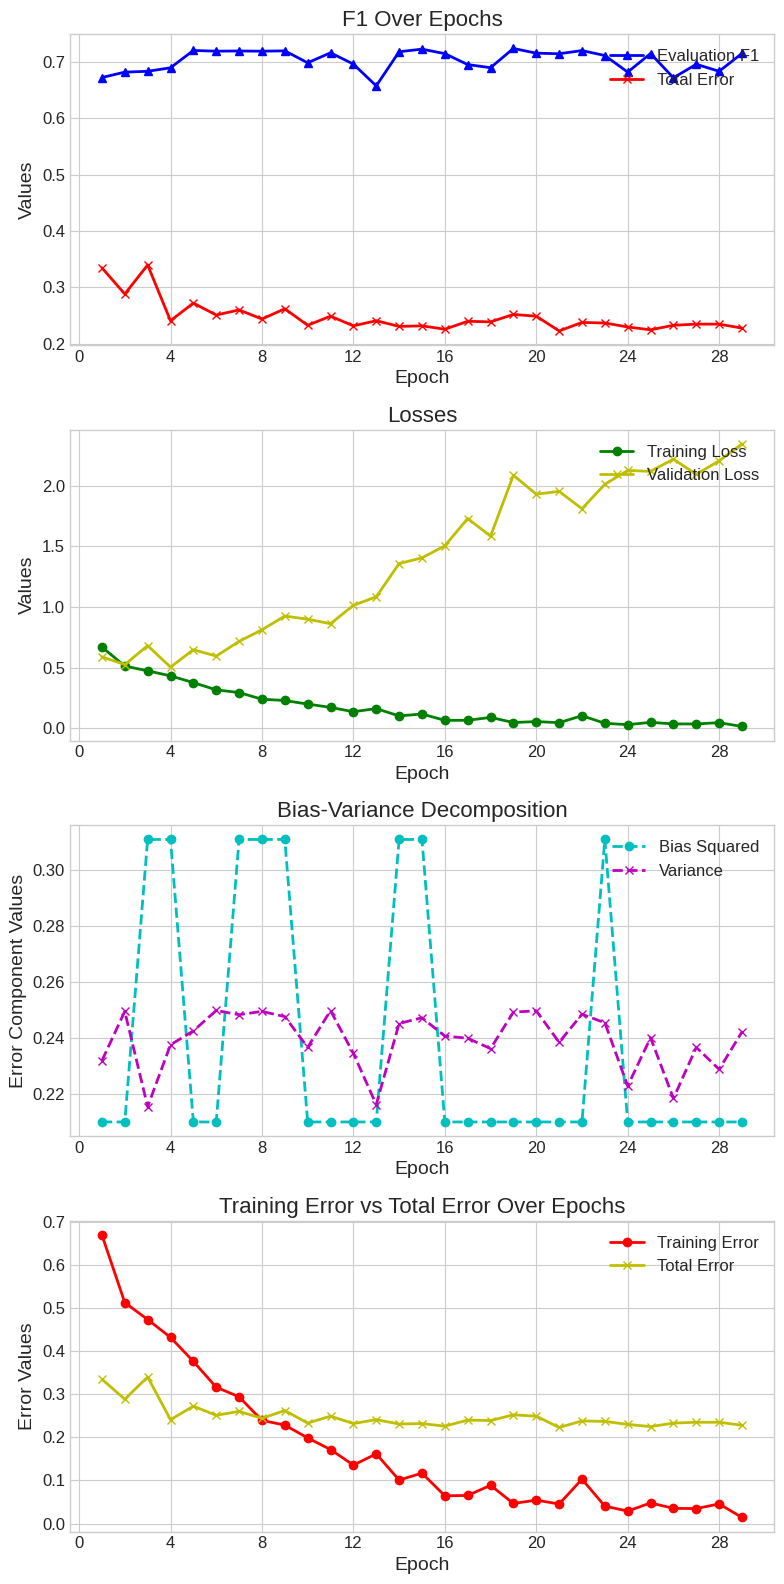



Run 2/5, seed=42 from [0, 42, 123, 1001, 2024]



Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


For task qqp validation set, sequence 1, marked as question1:
  The mean token count is 13.486
  The standard deviation is 6.552389182580656
  The max token count is 63
  The min token count is 1.

The max token count across splits is 205.
TOKEN_COUNT: 128



...

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


Training with seed 42...



Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.709900,0.684644,0.636364,0.580645
2,0.587100,0.523821,0.683742,0.713710
3,0.467000,0.477595,0.655647,0.747984
4,0.418700,0.511719,0.722652,0.746976
5,0.347100,0.493100,0.729216,0.770161
6,0.323100,0.511707,0.740385,0.782258
7,0.250500,0.710321,0.727689,0.760081
8,0.204800,0.819774,0.724571,0.757056
9,0.162200,0.761259,0.685950,0.770161
10,0.123900,1.080503,0.722359,0.772177



Evaluating with seed 42...



Results:

{'eval_f1': 0.7403846153846153, 'eval_loss': 0.5117071866989136, 'eval_accuracy': 0.782258064516129, 'eval_runtime': 4.3053, 'eval_samples_per_second': 232.27, 'eval_steps_per_second': 14.633, 'epoch': 16.0}

eval_f1: 0.7403846153846153
eval_loss: 0.5117071866989136
eval_accuracy: 0.782258064516129
eval_runtime: 4.3053
eval_samples_per_second: 232.27
eval_steps_per_second: 14.633
epoch: 16.0

For qqp, K=1000, seed=42, the best f1 is: 74.0
------------------------------------------------------------------


Plotting...



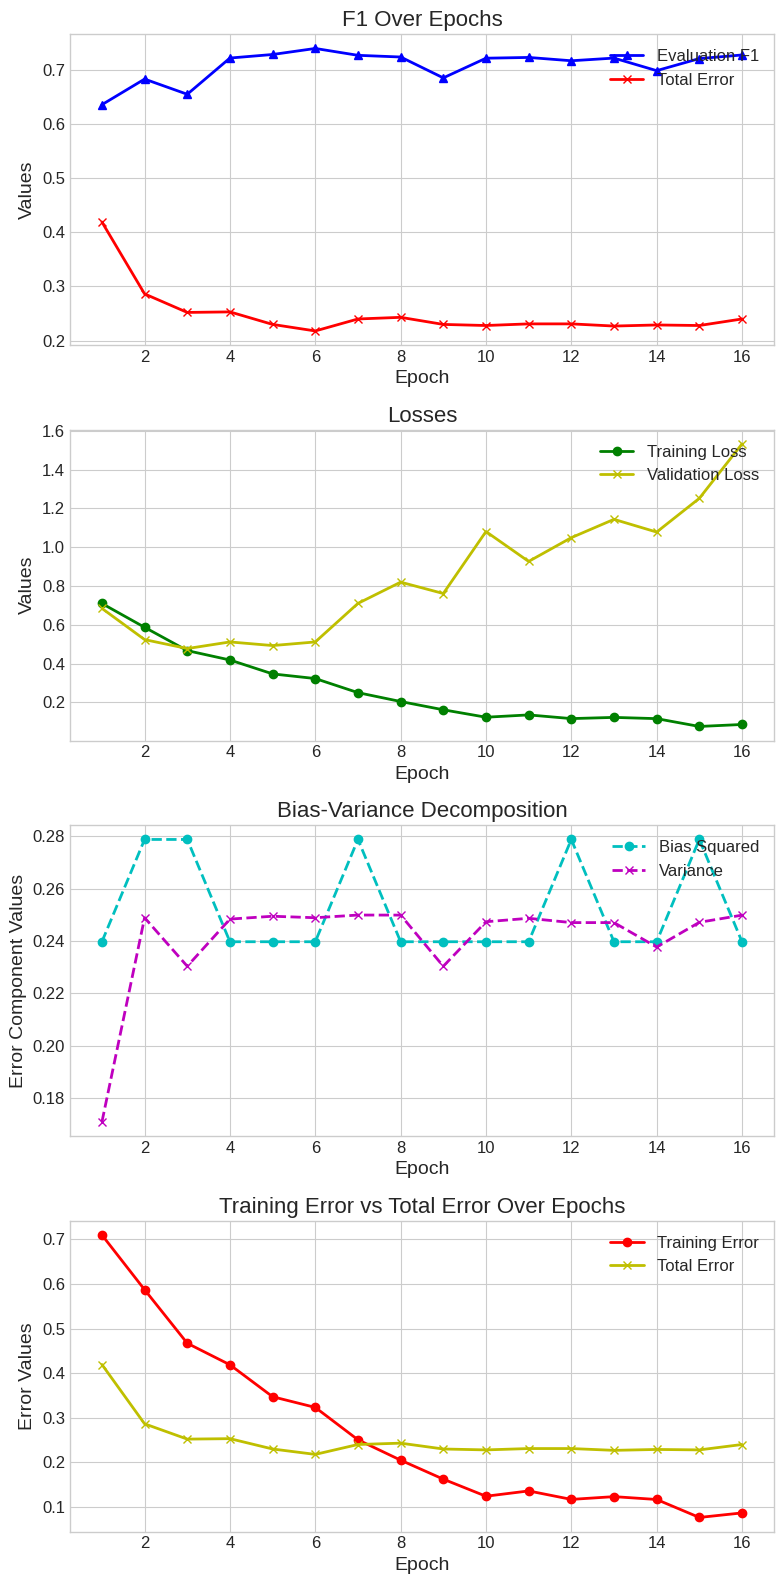



Run 3/5, seed=123 from [0, 42, 123, 1001, 2024]



Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


For task qqp validation set, sequence 1, marked as question1:
  The mean token count is 13.185
  The standard deviation is 6.739048523345116
  The max token count is 78
  The min token count is 4.

The max token count across splits is 205.
TOKEN_COUNT: 128



...

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


Training with seed 123...



Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.712400,0.571727,0.641170,0.678427
2,0.573500,0.599824,0.643655,0.646169
3,0.492700,0.549913,0.664376,0.704637
4,0.455000,0.499145,0.621387,0.735887
5,0.345700,0.544456,0.627393,0.744960
6,0.300100,0.639967,0.616296,0.738911
7,0.258500,0.923429,0.665885,0.712702
8,0.227700,0.747073,0.651475,0.737903
9,0.198700,1.343720,0.665276,0.676411
10,0.156300,1.012316,0.663252,0.734879



Evaluating with seed 123...



Results:

{'eval_f1': 0.6717752234993615, 'eval_loss': 2.172445774078369, 'eval_accuracy': 0.7409274193548387, 'eval_runtime': 4.4085, 'eval_samples_per_second': 226.835, 'eval_steps_per_second': 14.291, 'epoch': 28.0}

eval_f1: 0.6717752234993615
eval_loss: 2.172445774078369
eval_accuracy: 0.7409274193548387
eval_runtime: 4.4085
eval_samples_per_second: 226.835
eval_steps_per_second: 14.291
epoch: 28.0

For qqp, K=1000, seed=123, the best f1 is: 67.2
------------------------------------------------------------------


Plotting...



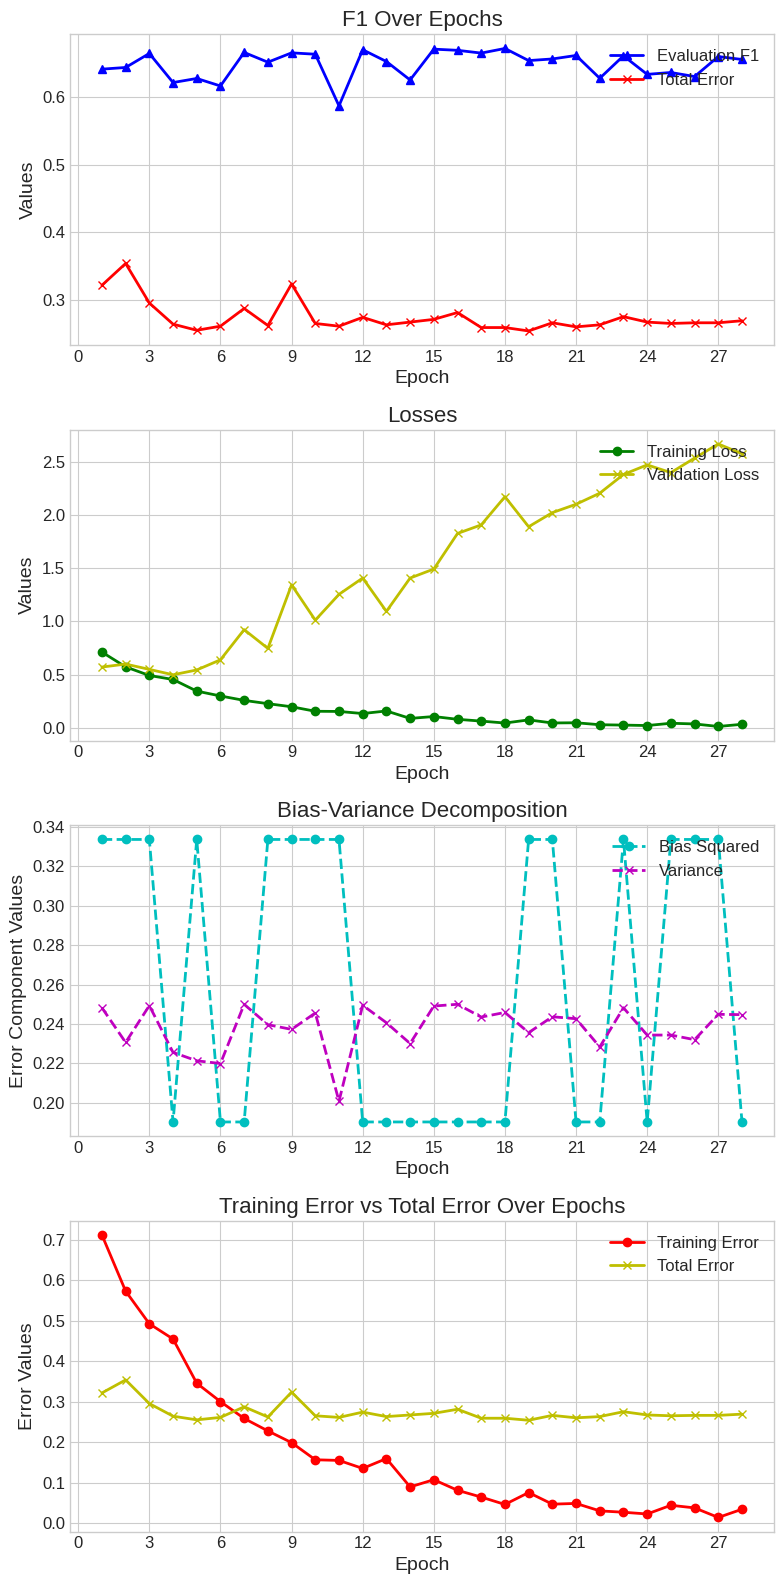



Run 4/5, seed=1001 from [0, 42, 123, 1001, 2024]



Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


For task qqp validation set, sequence 1, marked as question1:
  The mean token count is 13.365
  The standard deviation is 6.7066962805840555
  The max token count is 54
  The min token count is 4.

The max token count across splits is 205.
TOKEN_COUNT: 128



...

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


Training with seed 1001...



Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.707800,0.636650,0.639692,0.622984
2,0.529400,0.494865,0.595944,0.738911
3,0.463000,0.548276,0.675264,0.720766
4,0.421900,0.642648,0.677182,0.690524
5,0.326600,0.581811,0.695312,0.764113
6,0.272600,0.601226,0.681319,0.766129
7,0.242400,0.838625,0.691729,0.752016
8,0.202100,0.895737,0.666667,0.756048
9,0.166400,1.093867,0.684685,0.753024
10,0.156900,1.221324,0.623418,0.760081



Evaluating with seed 1001...



Results:

{'eval_f1': 0.6953125, 'eval_loss': 0.5818113684654236, 'eval_accuracy': 0.7641129032258065, 'eval_runtime': 4.3994, 'eval_samples_per_second': 227.306, 'eval_steps_per_second': 14.32, 'epoch': 15.0}

eval_f1: 0.6953125
eval_loss: 0.5818113684654236
eval_accuracy: 0.7641129032258065
eval_runtime: 4.3994
eval_samples_per_second: 227.306
eval_steps_per_second: 14.32
epoch: 15.0

For qqp, K=1000, seed=1001, the best f1 is: 69.5
------------------------------------------------------------------


Plotting...



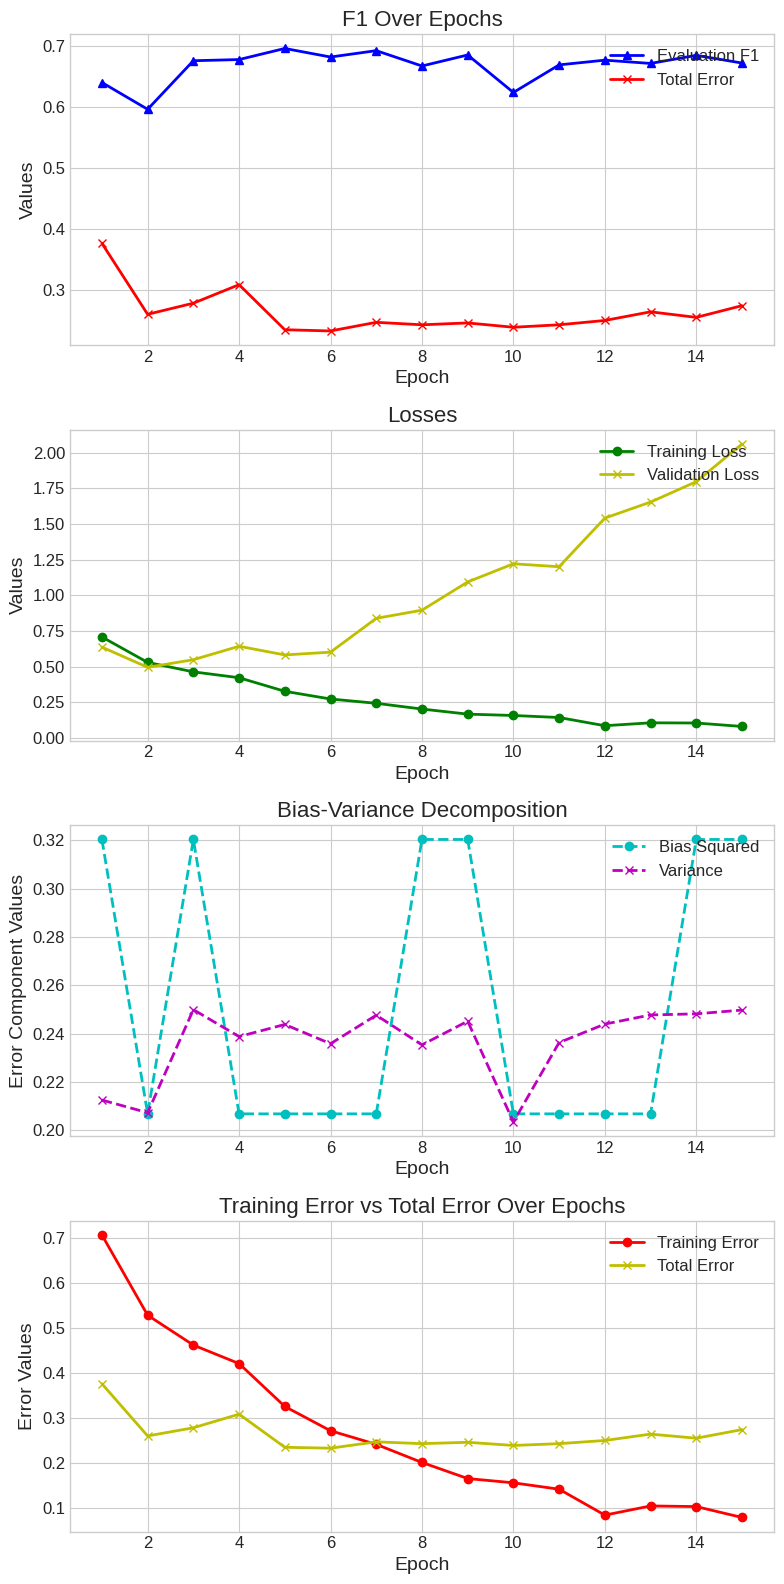



Run 5/5, seed=2024 from [0, 42, 123, 1001, 2024]



Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


For task qqp validation set, sequence 1, marked as question1:
  The mean token count is 13.077
  The standard deviation is 6.220857738286578
  The max token count is 45
  The min token count is 4.

The max token count across splits is 205.
TOKEN_COUNT: 128



...

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]


Training with seed 2024...



Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.676200,0.671242,0.640071,0.590726
2,0.561800,0.609414,0.666667,0.655242
3,0.454700,0.686082,0.680473,0.673387
4,0.389800,0.538283,0.685039,0.758065
5,0.316900,0.633502,0.658470,0.747984
6,0.270900,0.757877,0.681122,0.747984
7,0.238900,0.959353,0.697105,0.725806
8,0.202000,0.973139,0.700935,0.741935
9,0.146600,1.098509,0.686684,0.758065
10,0.131400,1.234777,0.654795,0.745968



Evaluating with seed 2024...



Results:

{'eval_f1': 0.7009345794392523, 'eval_loss': 0.9731389880180359, 'eval_accuracy': 0.7419354838709677, 'eval_runtime': 4.3428, 'eval_samples_per_second': 230.268, 'eval_steps_per_second': 14.507, 'epoch': 18.0}

eval_f1: 0.7009345794392523
eval_loss: 0.9731389880180359
eval_accuracy: 0.7419354838709677
eval_runtime: 4.3428
eval_samples_per_second: 230.268
eval_steps_per_second: 14.507
epoch: 18.0

For qqp, K=1000, seed=2024, the best f1 is: 70.1
------------------------------------------------------------------


Plotting...



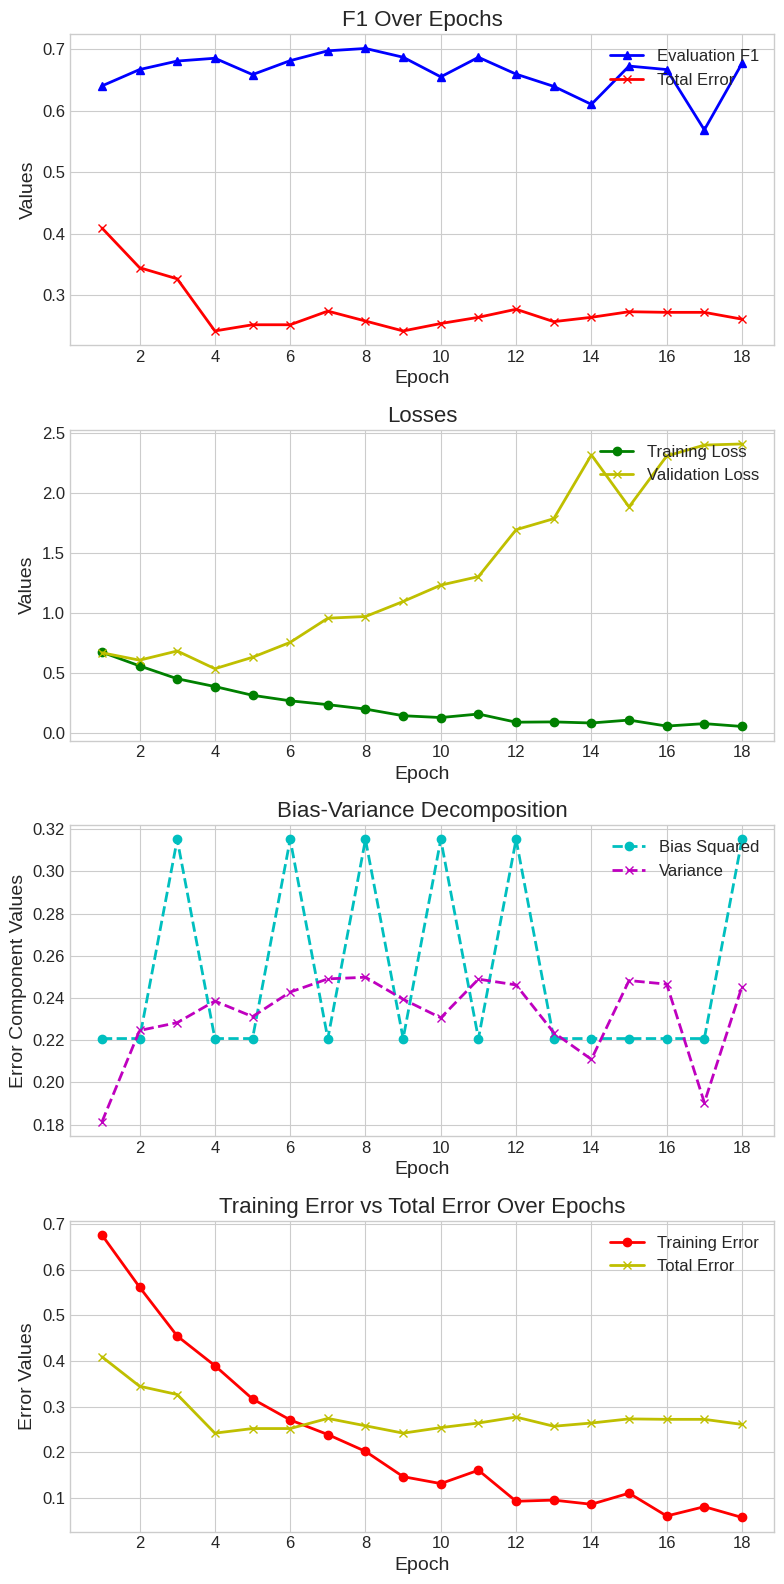



Done.

****************************************************************
Displaying results for qqp, K=1000...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 1, 'beta': 12, 'architecture': 'lora', 'use_gating': False, 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'weight_dropout_prob': 0.01, 'skip_prob': 0.03, 'noise_std': 0.03, 'p': 0.05, 'non_linearity': 'leakyrelu', 'training_set_size': 1000, 'batch_size': 16, 'log': False}

****************************************************************

{'eval_f1': [0.7234513274336283, 0.7403846153846153, 0.6717752234993615, 0.6953125, 0.7009345794392523], 'eval_loss': [2.0860788822174072, 0.5117071866989136, 2.172445774078369, 0.5818113684654236, 0.9731389880180359], 'eval_accuracy': [0.7479838709677419, 0.782258064516129, 0.7409274193548387, 0.7641129032258065, 0.7419354

In [10]:
TASK_NAME = "qqp"
# The above must be one of the following:
#
# ["sst-2", "mrpc", "cola", "rte", "qnli", "sts-b", "mnli", "qqp"]
DEV = True # set to True if you want to use the dev set, false otherwise


# K, number of examples to train on, use on of the: [100, 500, 1000, "all"]
K = 1000 # can be anything but other papers used those
SEEDS = [0, 42, 123, 1001, 2024] # can be anything i used these


TASK = GlueTask(TASK_NAME,
                hyperparameters=HYPERPARAMETERS,
                k=K,
                dev=DEV,
                weight_dropout_prob=0.01,
                noise_std=0.03,
                skip_prob=0.03,
                p = 0.05,
                patience=10,
                seeds=SEEDS)

######################################################################

results_summary = None

runs, last_model = TASK.run_experiments()

TASK.display_summary(results_summary)

all, results_summary = TASK.display_results(runs, TASK.k)

In [3]:
print(HYPERPARAMETERS["GLUE"][TASK_NAME.replace("-","")]) #0.815982 @ 28
all, results_summary = TASK.display_results(runs, K)

{'learning_rate': 0.0003, 'weight_decay': 0.01, 'warmup_ratio': 0.06, 'batch_size': 16, 'beta': 8}

****************************************************************
Displaying results for rte, K=1000...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 1, 'beta': 8, 'architecture': 'lora', 'use_gating': False, 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'weight_dropout_prob': 0.01, 'skip_prob': 0.03, 'noise_std': 0.03, 'p': 0.05, 'non_linearity': 'leakyrelu', 'training_set_size': 1000, 'batch_size': 16, 'log': False}

****************************************************************

{'eval_accuracy': [0.6360294117647058, 0.6323529411764706, 0.6801470588235294, 0.6544117647058824, 0.6176470588235294], 'eval_loss': [0.9514707922935486, 0.7716295123100281, 3.3219265937805176, 0.6987490653991699, 0.939475417137146], '

## Specify GLUE Task

To choose GLUE task for training and evaluation
TASK_NAME is in ["sst-2", "mrpc", "cola", "rte", "qnli", "sts-b", "mnli", "qqp"]



In [ ]:

def rescale(self,
        weights: torch.Tensor,
        sigma: float = 0.02,
        skip_prob: float = 0.1,
        weight_dropout_prob: float = 0.01) -> torch.Tensor:
    """
    Rescales the weights to have a standard deviation of sigma using the z-score.
    A method to control the variance of the weights with probabilistic rescaling
    and a dropout mechanism.

    Args:
        weights (torch.Tensor): Weights to rescale.
        sigma (float, optional): Desired standard deviation. Defaults to 0.05.
        dtype (torch.dtype, optional): Data type. Defaults to None.
        noise_std (float, optional): Standard deviation of the Gaussian noise added to sigma. Defaults to 0.01.
        dropout_prob (float, optional): Probability of dropping out the rescaling for a given weight. Defaults to 0.1.

    Returns:
        torch.Tensor: Rescaled weights
    """
    if sigma == 0 or self.skip(skip_prob):
        return weights

    if torch.std(weights).item() < sigma:
        return weights

    return self._mask_overlay(original_weights=weights,
                              new_weights=self._rescale(weights=weights, sigma=sigma),
                              weight_dropout_prob=weight_dropout_prob)

def regularize(self,
                weights: torch.Tensor,
                noise_std: float = 0.03,
                weight_dropout_prob: float = 0.01,
                skip_prob: float = 0.03) -> torch.Tensor:

    if not self.training or self.skip(skip_prob):
        return weights

    return self._mask_overlay(original_weights=weights,
                              new_weights=self._inject_noise(weights=weights, noise_std=noise_std),
                              weight_dropout_prob=weight_dropout_prob)

# helper functions

def _rescale(self, weights: torch.Tensor, sigma: float) -> torch.Tensor:
        u = torch.mean(weights, dtype=weights.dtype)
        z = (weights - u) / (torch.std(weights) + 1e-12)
        return z * sigma + u

def _inject_noise(self, weights: torch.Tensor, noise_std: float = 0.01) -> torch.Tensor:
    if not self.training:
        return weights
    s = weights.std().item()
    s = s + torch.normal(mean=0.0, std=noise_std * s, size=(1,), device=weights.device).item()
    return self._rescale(weights=weights, sigma=s)

def _mask_overlay(self,
                  original_weights: torch.Tensor,
                  new_weights: torch.Tensor,
                  weight_dropout_prob: float = 0.01) -> torch.Tensor:
    if not self.training:
        return new_weights

    mask = torch.bernoulli(torch.full_like(original_weights,
                                            1 - weight_dropout_prob,
                                            dtype=original_weights.dtype,
                                            device=original_weights.device))
    return mask * new_weights + (1 - mask) * original_weights

# override com and forward methods

def com(self, weights: torch.Tensor, added: torch.Tensor, scaling: Optional[float]=None) -> torch.Tensor:
    if self.training and self.epoch == 1:
        self.sigma_w = self.sigma_w + weights.std().item()

        if self._epoch_end():
            self.sigma_w = (self.sigma_w / self.batches_per_epoch)

    if self.training and self.epoch > 1:
        w = self.rescale(weights=weights,
                          sigma=self.sigma_w,
                          skip_prob=1 - self.p)
    else:
        w = weights

    if self.training:
        w = self.regularize(weights=w)

    if scaling is None:
        scaling = self.scaling


    return w + added * scaling

def forward(self, hidden_states: Optional[torch.Tensor], layer_input: torch.Tensor):
    self._increment_training_step_maybe()


    if hidden_states is None:
        hidden_states = layer_input

    dw = hidden_states @ torch.t(self.lora_A) @ torch.t(self.lora_B)
    sigma_dw = dw.std().item()

    if self.training and self.epoch == 1:
        self.batch_sigmas[self.n_batches - 1] = sigma_dw
        self.sigma_h = torch.mean(self.batch_sigmas).item()

    dw = self.rescale(weights=dw, sigma=self.sigma_h, skip_prob=self.p)
    hidden_states = self.regularize(weights=dw)
    self.delta_w = hidden_states.clone()


    if self.use_gating:
        gate = torch.sigmoid(self.gate(layer_input))
        gate = torch.mean(gate, dim=1).unsqueeze(-1)
        hidden_states = hidden_states * gate
    else:
        gate = None

    return hidden_states, gate

## Use this to quickly show results of last run

useful if javascript crashed/network issues

In [ ]:
all, results_summary = TASK.display_results(runs, K)

In [ ]:
all, results_summary = TASK.display_results(runs, K)


****************************************************************
Displaying results for sts-b, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 1, 'beta': 12, 'architecture': 'lora', 'use_gating': False, 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'weight_dropout_prob': 0.01, 'skip_prob': 0.05, 'noise_std': 0.005, 'non_linearity': 'leakyrelu', 'training_set_size': 100, 'batch_size': 8}

****************************************************************

{'eval_spearmanr': [0.6891553244074434], 'eval_loss': [1.7673759460449219], 'eval_pearson': [0.749403380691966], 'eval_runtime': [7.3371], 'eval_samples_per_second': [136.293], 'eval_steps_per_second': [17.037], 'epoch': [17.0], 'task': ['sts-b'], 'seed': [42], 'k': [100]}

mean_eval_spearmanr: 0.6891553244074434 std_eval_spearmanr: 0.0
mean_eval_loss: 1.7

## Plot Variances

Per layer of the adapter and aggregated

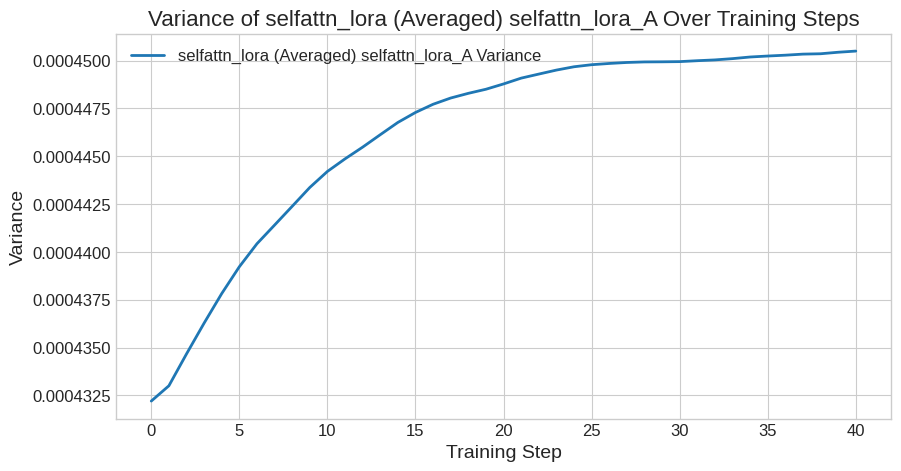

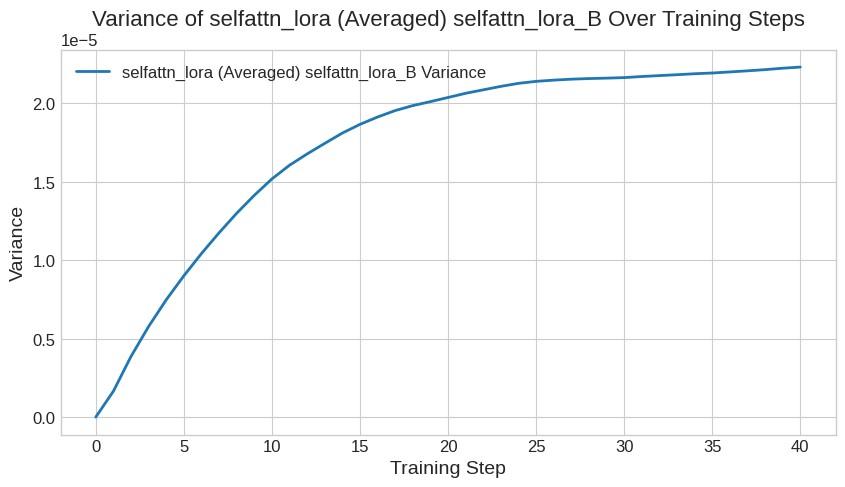

No variance data found for selfattn_lora (Averaged) selfattn_normed_dw


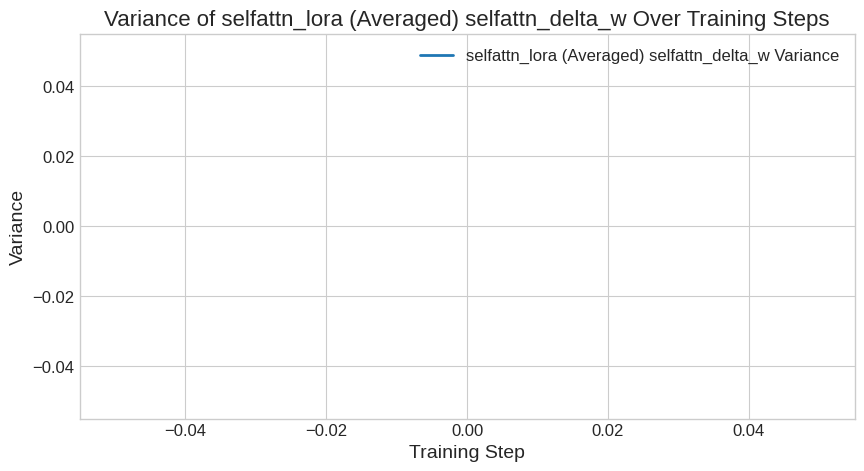

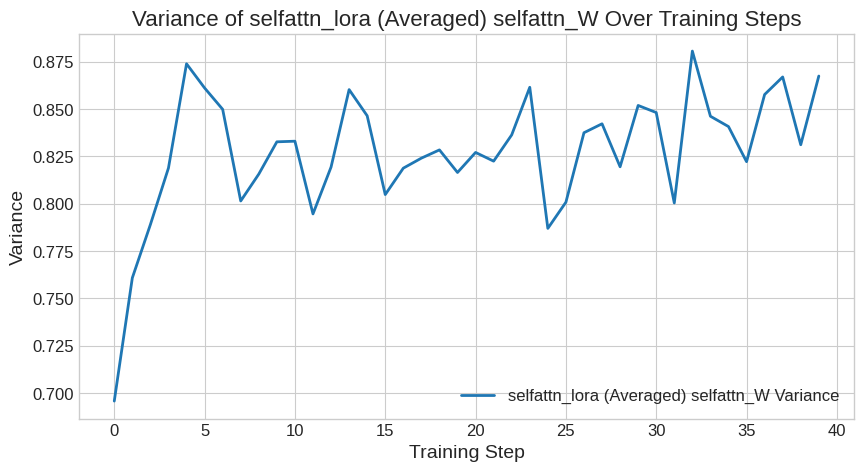

No variance data found for selfattn_lora (Averaged) selfattn_dw_std
No variance data found for selfattn_lora (Averaged) selfattn_sigma_h


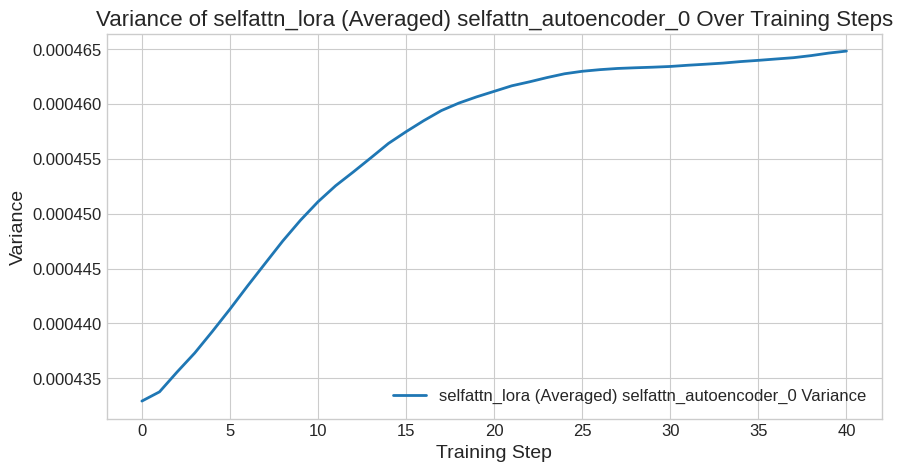

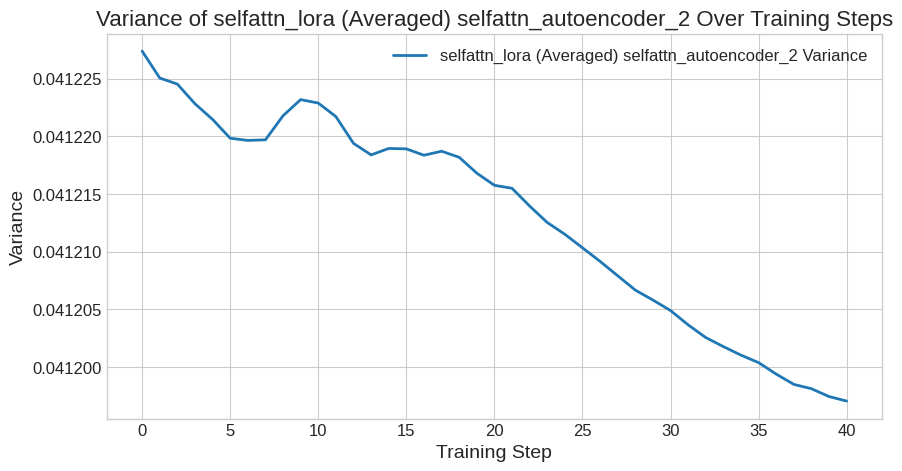

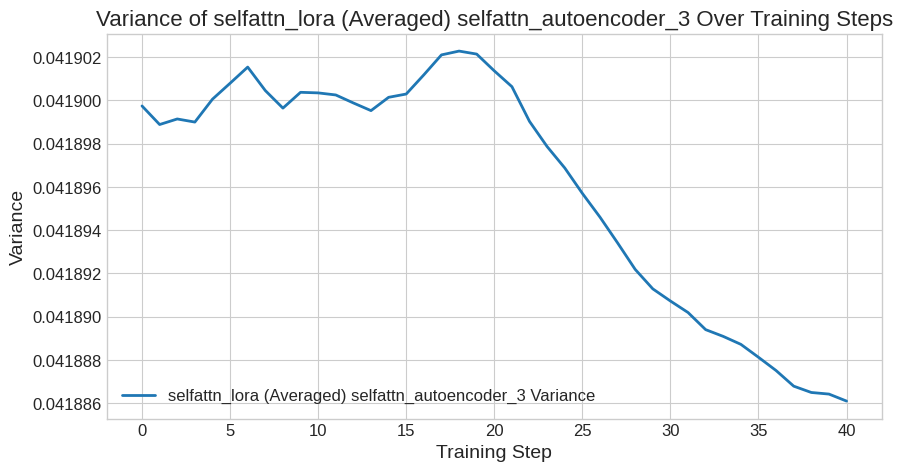

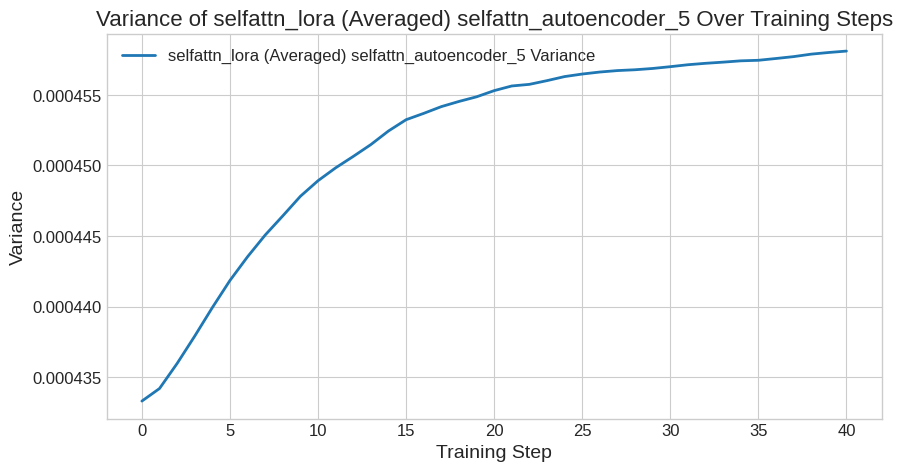

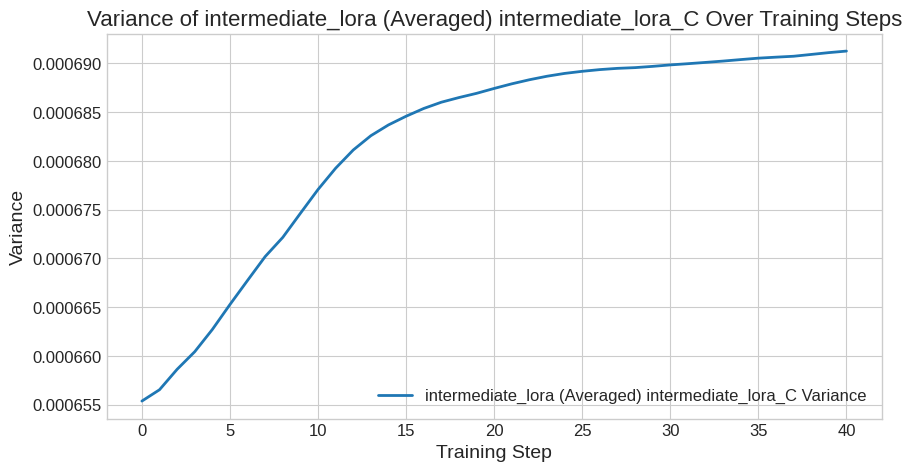

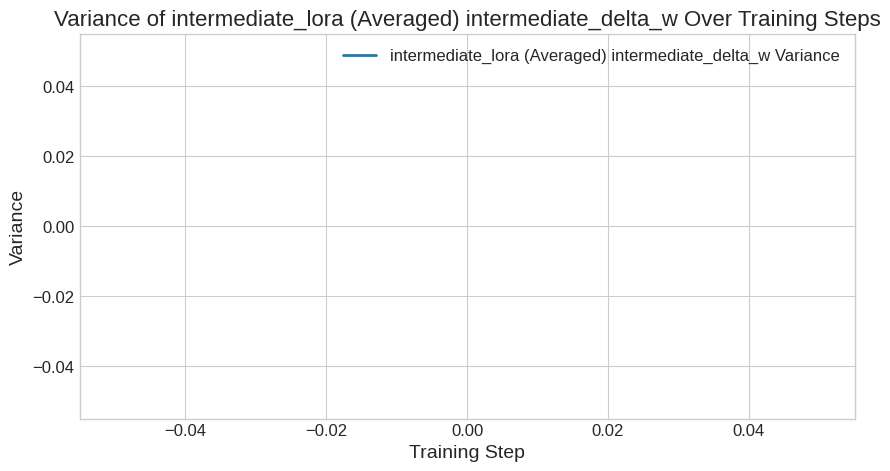

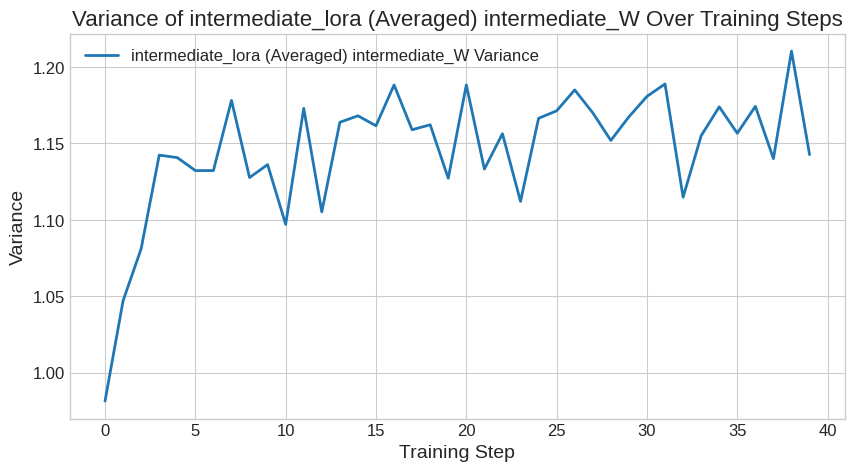

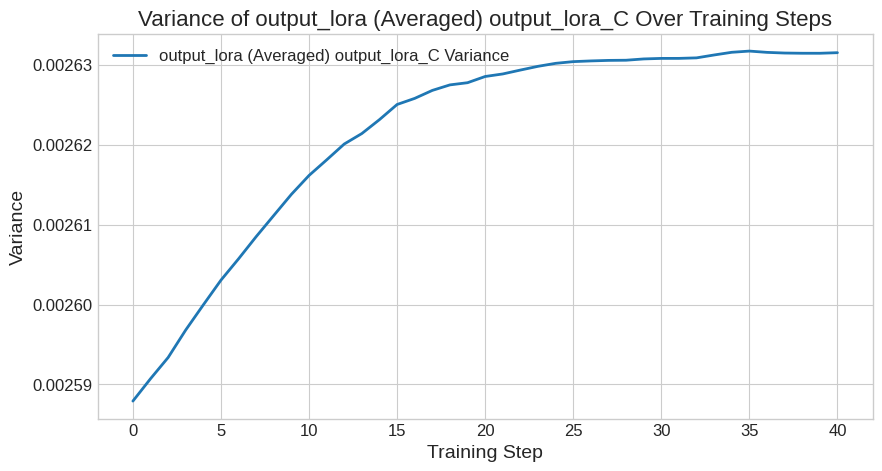

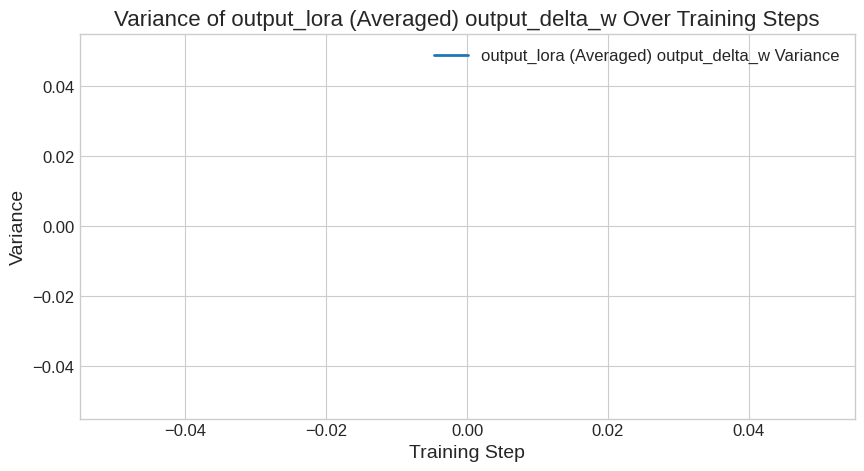

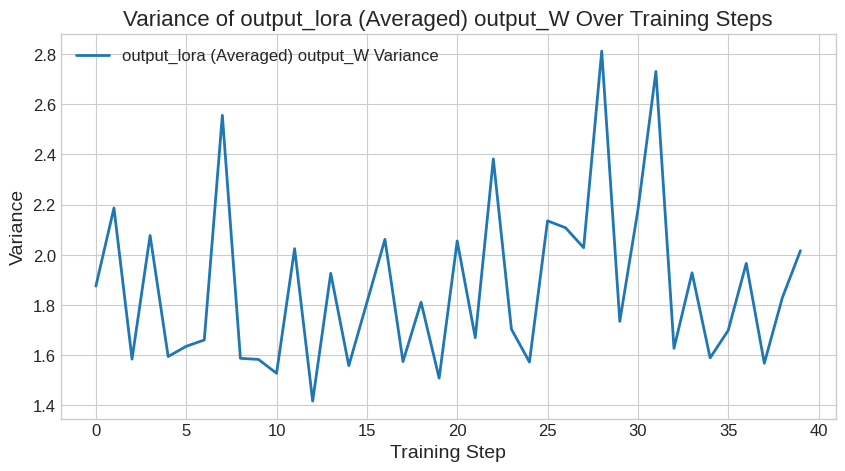

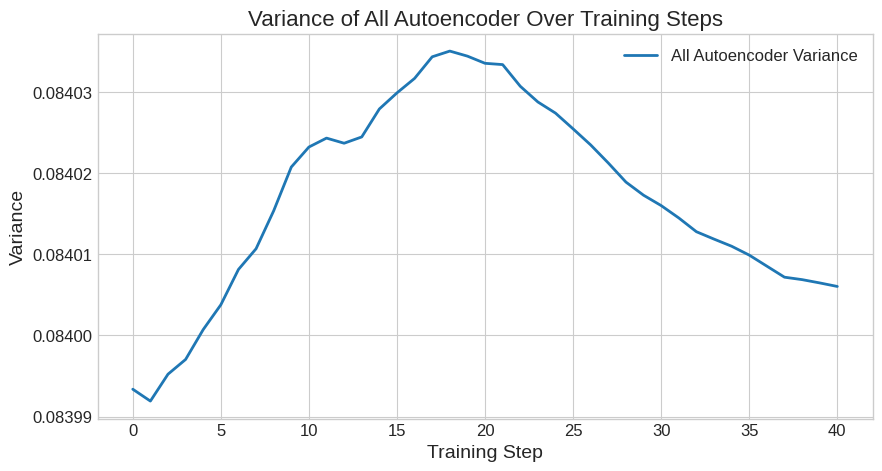

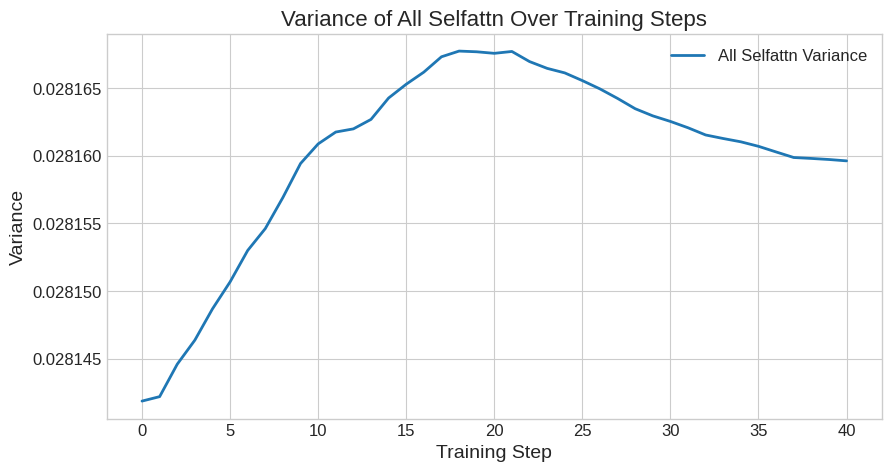

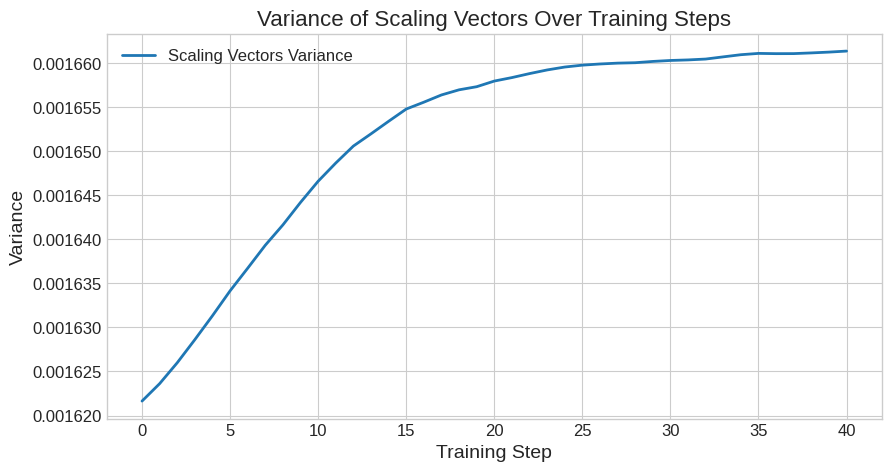

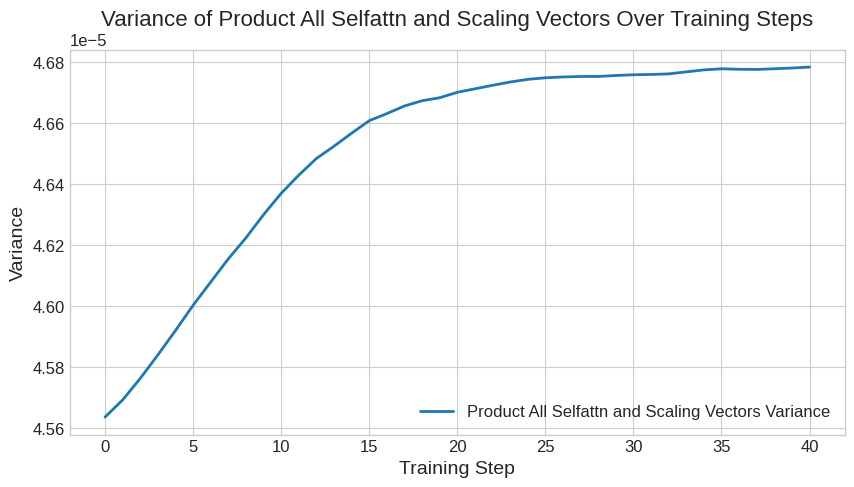

In [ ]:
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from collections import defaultdict

def average_variances(adapter_dict, lora_type):
    """
    Averages the variances of all instances of a specified LoRA type in the adapter dictionary.

    Args:
        adapter_dict (dict): Dictionary of LoRA adapters organized by layers and types.
        lora_type (str): Type of the LoRA to average (e.g., 'selfattn_lora', 'intermediate_lora', 'output_lora').

    Returns:
        dict: Dictionary containing averaged variance lists for each component.
        str: Description of the averaged LoRA for labeling purposes.
    """
    with torch.no_grad():
        variance_sums = defaultdict(list)
        count = 0

        for layer_idx, lora_types in adapter_dict.items():
            if lora_type in lora_types:
                lora_instances = lora_types[lora_type]
                # Handle both ModuleList and single Module
                if isinstance(lora_instances, nn.ModuleList):
                    instances = lora_instances
                else:
                    instances = [lora_instances]

                for lora_instance in instances:
                    if hasattr(lora_instance, 'variances'):
                        for key, var_list in lora_instance.variances.items():
                            # Convert each tensor in the list to a numpy array if it's a tensor
                            var_list = [v.cpu().numpy() if isinstance(v, torch.Tensor) else v for v in var_list]
                            # Pad the list to the maximum length found so far
                            max_length = max(len(v) for v in variance_sums[key]) if key in variance_sums else 0
                            if len(var_list) < max_length:
                                var_list.extend([0] * (max_length - len(var_list)))
                            variance_sums[key].append(var_list)
                        count += 1

        # Average the variances
        averaged_variances = {}
        for key, lists in variance_sums.items():
            # Pad all lists to the maximum length
            max_length = max(len(l) for l in lists)
            for l in lists:
                if len(l) < max_length:
                    l.extend([0] * (max_length - len(l)))
            averaged_variances[key] = np.mean(lists, axis=0)

        return averaged_variances, f"{lora_type} (Averaged)"

def plot_averaged_variances(averaged_variances, lora_name, variance_keys):
    """
    Plots the averaged variance of various components for a given LoRA type.

    Args:
        averaged_variances (dict): Dictionary containing averaged variance lists for each component.
        lora_name (str): The name of the LoRA type for labeling purposes.
        variance_keys (list): List of variance keys to plot.
    """
    with torch.no_grad():
        for key in variance_keys:
            if key in averaged_variances:
                variances = averaged_variances[key]
                plt.figure(figsize=(10, 5))
                plt.plot(range(len(variances)), variances, label=f"{lora_name} {key} Variance")
                plt.xlabel("Training Step")
                plt.ylabel("Variance")
                plt.title(f"Variance of {lora_name} {key} Over Training Steps")
                plt.legend()
                plt.grid(True)
                plt.show()
            else:
                print(f"No variance data found for {lora_name} {key}")

def plot_custom_variance(name, values):
    """
    Plots custom variance metrics.

    Args:
        name (str): The name of the metric for labeling purposes.
        values (np.ndarray): The variance values to plot.
    """
    with torch.no_grad():
        plt.figure(figsize=(10, 5))
        plt.plot(range(len(values)), values, label=f"{name} Variance")
        plt.xlabel("Training Step")
        plt.ylabel("Variance")
        plt.title(f"Variance of {name} Over Training Steps")
        plt.legend()
        plt.grid(True)
        plt.show()

with torch.no_grad():
    # Usage example
    lora_name = f"loria-{TASK.name}"

    last_model = last_model.to("cpu")
    adapter_dict = last_model.get_adapter(lora_name)

    # Average and plot for 'selfattn_lora'
    averaged_selfattn_variances, selfattn_name = average_variances(adapter_dict, 'selfattn_lora')
    selfattn_variance_keys = [
        'selfattn_lora_A',
        'selfattn_lora_B',
        'selfattn_normed_dw',
        'selfattn_delta_w',
        'selfattn_W',
        "selfattn_dw_std",
        "selfattn_sigma_h",
    ]
    # Find any selfattn lora to determine number of autoencoder layers
    any_selfattn_lora = next(iter(adapter_dict.values()))['selfattn_lora']
    if isinstance(any_selfattn_lora, nn.ModuleList):
        any_selfattn_lora = any_selfattn_lora[0]
    selfattn_variance_keys.extend([
        f'selfattn_autoencoder_{i}' for i in range(len(any_selfattn_lora.f)) if isinstance(any_selfattn_lora.f[i], nn.Linear)
    ])
    plot_averaged_variances(averaged_selfattn_variances, selfattn_name, selfattn_variance_keys)

    # Average and plot for 'intermediate_lora'
    averaged_intermediate_variances, intermediate_name = average_variances(adapter_dict, 'intermediate_lora')
    intermediate_variance_keys = [
        'intermediate_lora_C',
        'intermediate_delta_w',
        'intermediate_W',
    ]
    plot_averaged_variances(averaged_intermediate_variances, intermediate_name, intermediate_variance_keys)

    # Average and plot for 'output_lora'
    averaged_output_variances, output_name = average_variances(adapter_dict, 'output_lora')
    output_variance_keys = [
        'output_lora_C',
        'output_delta_w',
        'output_W',
    ]
    plot_averaged_variances(averaged_output_variances, output_name, output_variance_keys)

    # Calculate custom variance metrics
    # All autoencoder layers summed
    all_autoencoder = np.sum([
        averaged_selfattn_variances[key] for key in selfattn_variance_keys if 'autoencoder' in key
    ], axis=0)

    # Average of all_autoencoder, lora_A, and lora_B
    all_selfattn = np.mean([
        all_autoencoder,
        averaged_selfattn_variances['selfattn_lora_A'],
        averaged_selfattn_variances['selfattn_lora_B']
    ], axis=0)

    # Average of output_lora_C and intermediate_lora_C
    scaling_vectors = np.mean([
        averaged_output_variances['output_lora_C'],
        averaged_intermediate_variances['intermediate_lora_C']
    ], axis=0)

    # Product of all_selfattn and scaling_vectors
    product_all_selfattn_scaling_vectors = all_selfattn * scaling_vectors

    # Plot custom variance metrics
    plot_custom_variance('All Autoencoder', all_autoencoder)
    plot_custom_variance('All Selfattn', all_selfattn)
    plot_custom_variance('Scaling Vectors', scaling_vectors)
    plot_custom_variance('Product All Selfattn and Scaling Vectors', product_all_selfattn_scaling_vectors)


## Hyperparameter Tuning

Used for sts-b only since it was giving me trouble

In [ ]:
import os
import ray
import numpy as np
from ray import tune
from ray.train import RunConfig
from ray.tune import CLIReporter
from ray.tune.schedulers import PopulationBasedTraining, ASHAScheduler
from transformers import (
    AutoTokenizer,
    TrainingArguments,

    EvalPrediction,
    DataCollatorWithPadding,
)
from adapters import AutoAdapterModel
from adapters.configuration import AdapterConfig
from datasets import load_metric




def hyper_tune(task: GlueTask,num_samples: int=20, gpus_per_trial: int=1):
    # Load and prepare data
    dataset = task.get_dataset(random_seed=task.seed, num_samples=task.k)
    encoded_dataset, tokenizer = task.encode_dataset(dataset)
    task.disable_plots()
    training_args = task.get_training_args()
    # Define data collator
    data_collator = task.get_data_collator(tokenizer)
    early_stopping_callback = task.get_early_stopping_callback()

    # Initialize trainer
    trainer = AdapterTrainer(
        model=None,
        model_init=task.get_model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=task.compute_metrics,
        data_collator=data_collator,
        callbacks=[early_stopping_callback],
    )

    # Define Ray Tune config
    tune_config = {
        "learning_rate": tune.loguniform(1e-5, 1e-3),
        "weight_decay": tune.uniform(0.0, 0.1),
        "warmup_ratio": tune.choice([0.0, 0.06]),

    }

    def compute_objective(metrics):
        return metrics[task.get_metric_name()]

    # Define PBT scheduler
    scheduler = PopulationBasedTraining(
        time_attr="training_iteration",
        metric=task.get_eval_metric_name(),
        mode="max",
        perturbation_interval=2,
        hyperparam_mutations={
            "learning_rate": tune.loguniform(1e-5, 1e-3),
            "weight_decay": tune.uniform(0.0, 0.1),
            "warmup_ratio": tune.choice([0.0, 0.06]),
        },
    )

    # Define reporter
    reporter = CLIReporter(
        parameter_columns={
            "learning_rate": "lr",
            "weight_decay": "wd",
            "warmup_ratio": "wr",
        },
        metric_columns=[task.get_eval_metric_name(), "eval_loss", "epoch", "training_iteration"],
    )




    # Run hyperparameter search
    trainer.hyperparameter_search(
        hp_space=lambda _: tune_config,
        direction="maximize",
        backend="ray",
        storage_path="/content/ray",
        n_trials=num_samples,
        resources_per_trial={"cpu": 1, "gpu": gpus_per_trial},
        scheduler=scheduler,
        keep_checkpoints_num=1,
        checkpoint_score_attr="training_iteration",
        stop={"training_iteration": 40},
        progress_reporter=reporter,
        name="tune_transformer_pbt",
        log_to_file=True,
        compute_objective=compute_objective,
    )

hyper_tune(TASK,num_samples=20, gpus_per_trial=1)


## Run profiler if there is a need to optimize speed

In [ ]:
"""
This example is uses the official
huggingface transformers `hyperparameter_search` API.
"""
import os

import ray
from ray import tune
from ray.tune import CLIReporter
from ray.tune.examples.pbt_transformers.utils import (
    download_data,
    build_compute_metrics_fn,
)
from ray.tune.schedulers import PopulationBasedTraining
from transformers import (
    glue_tasks_num_labels,
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    GlueDataset,
    GlueDataTrainingArguments,
    TrainingArguments,
)


def tune_transformer(num_samples=8, gpus_per_trial=0, smoke_test=False):
    data_dir_name = "./data" if not smoke_test else "./test_data"
    data_dir = os.path.abspath(os.path.join(os.getcwd(), data_dir_name))
    if not os.path.exists(data_dir):
        os.mkdir(data_dir, 0o755)

    # Change these as needed.
    model_name = (
        "bert-base-uncased" if not smoke_test else "sshleifer/tiny-distilroberta-base"
    )
    task_name = "rte"

    task_data_dir = os.path.join(data_dir, task_name.upper())

    num_labels = glue_tasks_num_labels[task_name]

    config = AutoConfig.from_pretrained(
        model_name, num_labels=num_labels, finetuning_task=task_name
    )

    # Download and cache tokenizer, model, and features
    print("Downloading and caching Tokenizer")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Triggers tokenizer download to cache
    print("Downloading and caching pre-trained model")
    AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
    )

    def get_model():
        return AutoModelForSequenceClassification.from_pretrained(
            model_name,
            config=config,
        )

    # Download data.
    download_data(task_name, data_dir)

    data_args = GlueDataTrainingArguments(task_name=task_name, data_dir=task_data_dir)

    train_dataset = GlueDataset(
        data_args, tokenizer=tokenizer, mode="train", cache_dir=task_data_dir
    )
    eval_dataset = GlueDataset(
        data_args, tokenizer=tokenizer, mode="dev", cache_dir=task_data_dir
    )

    training_args = TrainingArguments(
        output_dir=".",
        learning_rate=1e-5,  # config
        do_train=True,
        do_eval=True,
        no_cuda=gpus_per_trial <= 0,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        num_train_epochs=2,  # config
        max_steps=-1,
        per_device_train_batch_size=16,  # config
        per_device_eval_batch_size=16,  # config
        warmup_steps=0,
        weight_decay=0.1,  # config
        logging_dir="./logs",
        skip_memory_metrics=True,
        report_to="none",
    )

    trainer = Trainer(

        model_init=get_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=build_compute_metrics_fn(task_name),
    )

    tune_config = {
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": tune.choice([2, 3, 4, 5]),
        "max_steps": 1 if smoke_test else -1,  # Used for smoke test.
    }

    scheduler = PopulationBasedTraining(
        time_attr="training_iteration",
        metric="eval_acc",
        mode="max",
        perturbation_interval=1,
        hyperparam_mutations={
            "weight_decay": tune.uniform(0.0, 0.3),
            "learning_rate": tune.uniform(1e-5, 5e-5),
            "per_device_train_batch_size": [16, 32, 64],
        },
    )

    reporter = CLIReporter(
        parameter_columns={
            "weight_decay": "w_decay",
            "learning_rate": "lr",
            "per_device_train_batch_size": "train_bs/gpu",
            "num_train_epochs": "num_epochs",
        },
        metric_columns=["eval_acc", "eval_loss", "epoch", "training_iteration"],
    )

    trainer.hyperparameter_search(
        hp_space=lambda _: tune_config,
        backend="ray",
        n_trials=num_samples,
        resources_per_trial={"cpu": 1, "gpu": gpus_per_trial},
        scheduler=scheduler,
        keep_checkpoints_num=1,
        checkpoint_score_attr="training_iteration",
        stop={"training_iteration": 1} if smoke_test else None,
        progress_reporter=reporter,
        local_dir="~/ray_results/",
        name="tune_transformer_pbt",
        log_to_file=True,
    )


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--smoke-test",
        default=True,
        action="store_true",
        help="Finish quickly for testing",
    )
    args, _ = parser.parse_known_args()

    ray.init()

    if args.smoke_test:
        tune_transformer(num_samples=1, gpus_per_trial=0, smoke_test=True)
    else:
        # You can change the number of GPUs here:
        tune_transformer(num_samples=8, gpus_per_trial=1)

In [ ]:
%tensorboard --logdir=log/sst-2

In [ ]:
class GlueAdapterTrainer(AdapterTrainer):
    def __init__(self, *args, task_name=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.task_name = task_name

        # Initialize the appropriate loss function
        if task_name in ["mrpc", "qqp", "cola"]:
            self.loss_fn = nn.BCEWithLogitsLoss()
        elif task_name == "stsb":
            self.loss_fn = nn.MSELoss()
        else:
            self.loss_fn = nn.CrossEntropyLoss()

    def compute_loss(self, model, inputs, return_outputs=True):
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs["labels"]

        # Compute the loss based on the task
        if self.task_name in ["mrpc", "qqp", "cola", "stsb"]:
            loss = self.loss_fn(logits.view(-1), labels.float().view(-1))
        else:
            loss = self.loss_fn(logits.view(-1, self.model.config.num_labels), labels)

        return (loss, outputs) if return_outputs else loss


















































## Use the following text area as scratchpad to record the results

Best to do things in this manner only when testing and trying things out.

Not recommended for actual serious runs. It is better to use something that is more organized and less prone to fail to save your records, for example, Google Sheets.

This text area intentionally left blank

###
###
###
###
###
###
###
###
###
###

End of text area

## End of Experiment: GLUE benchmark of LoRIA

## Misc.

Just various things I tried or am working on like optimizers

** At the very end some records of old results, but all results are in Weights and Biases for every run done over past two months**

In [ ]:

class FAdam(Optimizer):
    def __init__(
        self,
        params,
        lr: float = 1e-3,
        weight_decay: float = 0.1,
        betas: Tuple[float, float] = (0.9, 0.999),
        clip: float = 1.0,
        p: float = 0.5,
        eps: float = 1e-8,
        momentum_dtype: torch.dtype = torch.float32,
        fim_dtype: torch.dtype = torch.float32,
    ):
        """
        Args:
            params (iterable): iterable of parameters to optimize or dicts defining
                parameter groups
            lr (float, optional): learning rate (default: 1e-3)
            betas (Tuple[float, float], optional): coefficients used for computing
                running averages of gradient and its square (default: (0.9, 0.999))
            eps (float, optional): term added to the denominator to improve
                numerical stability (default: 1e-15)
            clip (float, optional): maximum norm of the gradient (default: 1.0)
            TODO - explain p

            # Usage
            TODO
        """
        defaults = dict(
            lr=lr,
            betas=betas,
            weight_decay=weight_decay,
            eps=eps,
            momentum_dtype=momentum_dtype,
            fim_dtype=fim_dtype,
            clip=clip,
            p=p,
        )

        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure: Optional[callable] = None) -> Optional[float]:
        """Performs a single optimization step.
        Args:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                # to fix linter, we do not keep the returned loss for use atm.
                loss = closure()

        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            lr = group["lr"]
            eps = group["eps"]
            clip = group["clip"]
            pval = group["p"]
            momentum_dtype = group["momentum_dtype"]
            fim_dtype = group["fim_dtype"]
            weight_decay = group["weight_decay"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                if p.grad.is_sparse:
                    raise RuntimeError("FAdam does not support sparse gradients")

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state.setdefault("step", torch.tensor(0.0))
                    state.setdefault(
                        "momentum", torch.zeros_like(p, dtype=momentum_dtype)
                    )
                    state.setdefault("fim", torch.ones_like(p, dtype=fim_dtype))


                # main processing -------------------------

                # update the steps for each param group update
                state["step"] += 1
                step = state["step"]

                momentum = state["momentum"]
                fim = state["fim"]
                grad = p.grad

                # begin FAdam algo -------------------------
                # 6 - beta2 bias correction per Section 3.4.4
                curr_beta2 = beta2 * (1 - beta2 ** (step - 1)) / (1 - beta2**step)

                # 7 - update fim
                fim.mul_(curr_beta2).add_(grad * grad, alpha=1 - curr_beta2)

                # 8 - adaptive epsilon
                rms_grad = torch.sqrt(torch.mean((grad * grad)))
                curr_eps = eps * min(1, rms_grad)

                # 9 - compute natural gradient
                fim_base = fim**pval + curr_eps  # **(2*pval)

                grad_nat = grad / fim_base

                # 10 - clip the natural gradient
                rms = torch.sqrt(torch.mean(grad_nat**2))
                divisor = max(1, rms)
                divisor = divisor / clip
                grad_nat = grad_nat / divisor

                # 11 - update momentum
                momentum.mul_(beta1).add_(grad_nat, alpha=1 - beta1)

                # 12 - weight decay
                grad_weights = p / fim_base

                # 13 - clip weight decay
                rms = torch.sqrt(torch.mean(grad_weights**2))
                divisor = max(1, rms)
                divisor /= clip
                grad_weights = grad_weights / divisor

                # 14 - compute update
                full_step = momentum + (weight_decay * grad_weights)
                lr_step = lr * full_step

                # 15 - update weights
                p.sub_(lr_step)

        return loss



def setup_dataloaders(model, tokenizer, encoded_dataset, random_seed):
  from torch.utils.data import DataLoader

  train_dataset = encoded_dataset["train"].shuffle(seed=random_seed)
  eval_dataset = encoded_dataset["validation"].shuffle(seed=random_seed)
  if TASK.dev:
    eval_dataset = eval_dataset.select(range(1000))


  train_dataloader = DataLoader(train_dataset,
                                shuffle=True,
                                batch_size=TASK.get_hyperparameter("batch_size"))
  eval_dataloader = DataLoader(eval_dataset, batch_size=TASK.get_hyperparameter("batch_size"))
  return train_dataloader, eval_dataloader



def training_loop(model, train_dataloader):
  from tqdm.auto import tqdm
  from transformers import get_scheduler
  from torch.optim import AdamW

  num_epochs = 60
  num_training_steps = num_epochs * len(train_dataloader)
  num_warmup_steps = int(num_training_steps * TASK.get_hyperparameter("warmup_ratio"))
  progress_bar = tqdm(range(num_training_steps))

  optimizer = AdamW(model.parameters(),
                    lr=TASK.get_hyperparameter("learning_rate"))

  lr_scheduler = get_scheduler(
      name="linear",
      optimizer=optimizer,
      num_warmup_steps=num_warmup_steps,
      num_training_steps=num_training_steps,
  )

  model.train()
  for epoch in range(num_epochs):
      for batch in train_dataloader:
          batch = {k: v.to("cuda:0") for k, v in batch.items()}
          outputs = model(**batch)
          loss = outputs.loss
          loss.backward()

          optimizer.step()
          lr_scheduler.step()
          optimizer.zero_grad()
          progress_bar.update(1)

  return model

## Old results and some notes on hyperparameters

In [ ]:
***************************************************************
Displaying results for sst-2, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 1, 'beta': 12, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'training_set_size': 100, 'batch_size': 16, 'sigma': 'loria'}

****************************************************************

{'eval_loss': [0.765600860118866, 0.7130494117736816, 0.4897659420967102, 0.39985254406929016, 0.6215701103210449], 'eval_accuracy': [0.8506944444444444, 0.8425925925925926, 0.8263888888888888, 0.8414351851851852, 0.8391203703703703], 'eval_runtime': [3.0, 2.9472, 2.8859, 3.1501, 2.9183], 'eval_samples_per_second': [290.663, 295.878, 302.155, 276.816, 298.804], 'eval_steps_per_second': [18.333, 18.662, 19.058, 17.46, 18.847], 'epoch': [60.0, 60.0, 38.0, 32.0, 49.0], 'task': ['sst-2', 'sst-2', 'sst-2', 'sst-2', 'sst-2'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 0.5979677736759186 std_eval_loss: 0.1362783812289723
mean_eval_accuracy: 0.8400462962962962 std_eval_accuracy: 0.007863559144195858
mean_eval_runtime: 2.9803 std_eval_runtime: 0.09281282239001254
mean_eval_samples_per_second: 292.86319999999995 std_eval_samples_per_second: 8.866489483442699
mean_eval_steps_per_second: 18.472 std_eval_steps_per_second: 0.5592112302162751
mean_epoch: 47.8 std_epoch: 11.356055653262713
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE sst-2, K=100: accuracy: 84.0 std_accuracy: 0.79

****************************************************************
Displaying results for sst-2, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 1, 'beta': 12, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'init_weights': -1, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'rescale_frequency': 3}

****************************************************************

{'eval_loss': [0.8019659519195557, 0.6658837795257568, 0.7392714023590088, 0.9019482731819153, 0.8189060091972351], 'eval_accuracy': [0.8495370370370371, 0.8321759259259259, 0.8136574074074074, 0.8321759259259259, 0.8564814814814815], 'eval_runtime': [1.4017, 1.4257, 1.4427, 1.4885, 1.4305], 'eval_samples_per_second': [622.086, 611.639, 604.441, 585.833, 609.584], 'eval_steps_per_second': [19.975, 19.64, 19.409, 18.811, 19.574], 'epoch': [52.0, 47.0, 46.0, 60.0, 60.0], 'task': ['sst-2', 'sst-2', 'sst-2', 'sst-2', 'sst-2'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 0.7855950832366944 std_eval_loss: 0.07923681920223546
mean_eval_accuracy: 0.8368055555555556 std_eval_accuracy: 0.015019563145841056
mean_eval_runtime: 1.43782 std_eval_runtime: 0.028626589038863844
mean_eval_samples_per_second: 606.7166 std_eval_samples_per_second: 11.916153449834399
mean_eval_steps_per_second: 19.4818 std_eval_steps_per_second: 0.3826347605746248
mean_epoch: 53.0 std_epoch: 6.06630035524124
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE sst-2, K=100: accuracy: 83.7 std_accuracy: 1.50





****************************************************************
Displaying results for mrpc, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 16, 'beta': 12, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'training_set_size': 100, 'batch_size': 16, 'sigma': 'loria'}

****************************************************************

{'eval_loss': [2.499264717102051, 0.6296728253364563, 0.7265410423278809, 0.6044701933860779, 0.6046777367591858], 'eval_accuracy': [0.7325, 0.685, 0.7125, 0.6875, 0.69], 'eval_f1': [0.8325508607198749, 0.8130563798219584, 0.8211508553654744, 0.8137108792846497, 0.8138138138138139], 'eval_runtime': [1.2376, 1.33, 1.2827, 1.279, 1.2796], 'eval_samples_per_second': [329.681, 306.756, 318.076, 318.997, 318.856], 'eval_steps_per_second': [21.009, 19.548, 20.27, 20.328, 20.319], 'epoch': [53.0, 21.0, 26.0, 26.0, 24.0], 'task': ['mrpc', 'mrpc', 'mrpc', 'mrpc', 'mrpc'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 1.0129253029823304 std_eval_loss: 0.7445273550676909
mean_eval_accuracy: 0.7015 std_eval_accuracy: 0.018343936327844156
mean_eval_f1: 0.8188565578011543 std_eval_f1: 0.00746119390782399
mean_eval_runtime: 1.28178 std_eval_runtime: 0.029292893336097765
mean_eval_samples_per_second: 318.4732 std_eval_samples_per_second: 7.259286835495622
mean_eval_steps_per_second: 20.294800000000002 std_eval_steps_per_second: 0.46262183260196515
mean_epoch: 30.0 std_epoch: 11.64474130240771
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE mrpc, K=100: f1: 81.8 std_f1: 0.44

***************************************************************




****************************************************************
Displaying results for cola, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 8, 'beta': 8, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'training_set_size': 100, 'batch_size': 16, 'sigma': 'loria'}

****************************************************************

{'eval_loss': [0.8612615466117859, 2.193504810333252, 1.7526201009750366, 1.0052940845489502, 1.6363863945007324], 'eval_matthews_correlation': [0.2833700116451145, 0.29262051136462724, 0.3381820656656181, 0.3508373783584128, 0.2822955142289797], 'eval_runtime': [3.3088, 3.3052, 3.3322, 3.3167, 3.2923], 'eval_samples_per_second': [315.22, 315.567, 313.009, 314.466, 316.804], 'eval_steps_per_second': [19.947, 19.969, 19.807, 19.899, 20.047], 'epoch': [21.0, 43.0, 43.0, 23.0, 35.0], 'task': ['cola', 'cola', 'cola', 'cola', 'cola'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 1.4898133873939514 std_eval_loss: 0.49306571675873134
mean_eval_matthews_correlation: 0.30946109625255047 std_eval_matthews_correlation: 0.029117725347181052
mean_eval_runtime: 3.3110400000000006 std_eval_runtime: 0.013191603390035571
mean_eval_samples_per_second: 315.01320000000004 std_eval_samples_per_second: 1.2548044309771829
mean_eval_steps_per_second: 19.933799999999998 std_eval_steps_per_second: 0.07939370252104444
mean_epoch: 33.0 std_epoch: 9.465727652959385
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE cola, K=100: matthews_correlation: 30.9 std_matthews_correlation: 2.91std_matthews_correlation: 4.00

****************************************************************
Displaying results for rte, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 8, 'beta': 12, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'training_set_size': 100, 'batch_size': 32, 'sigma': 'loria'}

****************************************************************

{'eval_loss': [0.7969622611999512, 0.9443976879119873, 0.9706454277038574, 0.6970672607421875, 1.4271841049194336], 'eval_accuracy': [0.609375, 0.5859375, 0.5859375, 0.55859375, 0.66015625], 'eval_runtime': [0.5729, 0.5717, 0.5736, 0.5791, 0.577], 'eval_samples_per_second': [483.497, 484.544, 482.939, 478.322, 480.061], 'eval_steps_per_second': [15.709, 15.743, 15.691, 15.541, 15.598], 'epoch': [17.0, 23.0, 22.0, 12.0, 32.0], 'task': ['rte', 'rte', 'rte', 'rte', 'rte'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 0.9672513484954834 std_eval_loss: 0.25062711925667464
mean_eval_accuracy: 0.6 std_eval_accuracy: 0.034107624926473554
mean_eval_runtime: 0.5748599999999999 std_eval_runtime: 0.0027557938965024073
mean_eval_samples_per_second: 481.87260000000003 std_eval_samples_per_second: 2.3152069972250886
mean_eval_steps_per_second: 15.6564 std_eval_steps_per_second: 0.07508821478767476
mean_epoch: 21.2 std_epoch: 6.675327707311455
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE rte, K=100: accuracy: 60.0 std_accuracy: 3.41



****************************************************************
Displaying results for qnli, K=100...

****************************************************************

ADAPTER CONFIGURATION:

{'alpha': 8, 'beta': 12, 'architecture': 'lora', 'selfattn_lora': True, 'intermediate_lora': True, 'output_lora': True, 'leave_out': [], 'r': 8, 'attn_matrices': ['v', 'k'], 'composition_mode': 'add', 'dropout': 0.1, 'use_gating': False, 'non_linearity': 'leakyrelu', 'eps': 1e-09, 'training_set_size': 100, 'batch_size': 32, 'sigma': 'loria'}

****************************************************************

{'eval_loss': [1.0454448461532593, 2.1227660179138184, 2.066614866256714, 0.5998541712760925, 1.4886356592178345], 'eval_accuracy': [0.7358870967741935, 0.7379032258064516, 0.7086693548387096, 0.7580645161290323, 0.7358870967741935], 'eval_runtime': [1.7257, 1.74, 1.7719, 1.8315, 1.8024], 'eval_samples_per_second': [579.482, 574.703, 564.379, 545.987, 554.83], 'eval_steps_per_second': [18.543, 18.39, 18.06, 17.472, 17.755], 'epoch': [28.0, 51.0, 51.0, 20.0, 26.0], 'task': ['qnli', 'qnli', 'qnli', 'qnli', 'qnli'], 'seed': [0, 42, 123, 1001, 2024], 'k': [100, 100, 100, 100, 100]}

mean_eval_loss: 1.4646631121635436 std_eval_loss: 0.5864569021881513
mean_eval_accuracy: 0.7352822580645161 std_eval_accuracy: 0.015715463927342816
mean_eval_runtime: 1.7743000000000002 std_eval_runtime: 0.039001692270977134
mean_eval_samples_per_second: 563.8761999999999 std_eval_samples_per_second: 12.352089789181417
mean_eval_steps_per_second: 18.044 std_eval_steps_per_second: 0.3948868192279906
mean_epoch: 35.2 std_epoch: 13.166624472506232
mean_seed: 638.0 std_seed: 784.8885271170677

****************************************************************
SUMMARY ROUNDED RESULT FOR GLUE qnli, K=100: accuracy: 73.5 std_accuracy: 1.57

In [ ]:
                },
                "stsb": {
                    "learning_rate": 2e-5,
                    "weight_decay": 0.0001,
                    "warmup_ratio": 0.0,
                    "batch_size": 8,
                    "beta": 16,
                },